# Shoaling across experiments: 2h vs 4h Episode Comparison

This notebook compares the current 24-episode, 2-hour analysis window against the full available recording window for 2026 shoaling-selection experiments. It focuses on bout-like (`02k20f`) and linear (`01k01f`) episode types, while keeping the episode filter easy to edit.

In [1]:
# Standard-library imports for paths, directory changes, and file pattern matching.
import os
import glob
from pathlib import Path

# Analysis and plotting libraries used throughout the notebook.
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.stats.api as sms

# Keep notebook plotting explicit and make local module edits reload automatically.
%config InteractiveShellApp.pylab_import_all = False
%matplotlib inline
%reload_ext autoreload
%autoreload 2

# Make imports work whether the notebook is launched from the repo root or Analyses/.
cwd = Path.cwd()
REPO_DIR = cwd.parent if cwd.name == 'Analyses' else cwd
os.chdir(REPO_DIR)

# Project helpers: path splitting, paper-style plotting defaults, and the batch processor.
import functions.matrixUtilities_joh as mu
import functions.paperFigureProps as pfp
import functions.si_slowdown as sis
import models.experiment_set as es

# Set global figure aesthetics before any plots are created.
pfp.paper()
sns.set_context('talk')
sns.set_style('ticks')


using plot settings for paper plots
standard figure sizes 
 figSq:  (5, 5) 
 figLs:  (5, 3) 
 figPt:  (3, 5)


## Paths And Analysis Settings

Set the metadata file, output locations, processing switches, episode filters, and plotting colors. 

In [2]:
# Plot color settings; edit these first when changing plot colors.
GENOTYPE_PALETTE = {'hi': '#E0A32D', 'lo': '#3B75AF'}
EPISODE_PALETTE = {'bout': "#7223CC", 'linear': "#22C7E4"}
MIDPOINT_REFERENCE_COLOR = 'red'
WINDOW_CUTOFF_COLOR = 'k'
ZERO_BASELINE_COLOR = 'k'
REFERENCE_LINE_ALPHA = 0.45
SEM_BAND_ALPHA = 0.18
PER_EXPERIMENT_SEM_BAND_ALPHA = 0.16
PLOT_CONFIDENCE_INTERVALS = True
REFERENCE_MINUTE = 60
PER_EXPERIMENT_REFERENCE_LINE_STYLE = {'ls': ':', 'color': MIDPOINT_REFERENCE_COLOR, 'linewidth': 1.2}

# Metadata workbook location. All experiment rows and animal annotations come from here.
metaFolder = '//nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsch/default/D2c/07_Data/Carlos/Behavior/ShoalingSelection/'
#metaFolder = '//nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsch/default/D2c/07_Data/Carlos/Behavior/QTL/'
metaFile = 'MetaData_CR.xlsx'
#metaFile = 'MetaData_QTL.xlsx'

# Separate folders for generated processing summaries and saved figure outputs.
BASE_PROCESSING_DIR = Path('//nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsch/default/D2c/03_Common_Use/temp/shoaling_selection/ShoalSelec_2h_vs_4h_processing/')
outputDir = Path('//nasdcsr.unil.ch/RECHERCHE/FAC/FBM/CIG/jlarsch/default/D2c/03_Common_Use/temp/shoaling_selection/ShoalSelec_2h_vs_4h_output/')

# RUN_PROCESSING controls whether the pipeline is invoked; RERUN_PROCESSING forces existing summaries to be recomputed.
RUN_PROCESSING = True
RERUN_PROCESSING = False

# Each episode is 5 minutes at 30 fps; the historical 2h window is the first 24 episodes.
EPISODE_DURATION_MIN = 5
FPS_FOR_READLIM = 30
EPISODES_2H = 24
FULL_CONDITION_KEY = '4h_all'

# Change this dictionary to analyze different episode codes.
# Keys may be written with or without the trailing 'f'.
EPISODE_FILTER = {
    '02k20f': 'bout',
    '01k01f': 'linear',
}

# Process all available episodes in the full condition; the 2h window is derived later by filtering episodes.
FULL_PROCESSING_SETTINGS = {
    'label': '4h/all',
    'episodes': -1,
    'readLim': None,
    'allowEpisodeSwitch': 1,
}

# Plot order and genotype filter used by downstream figures.
WINDOW_ORDER = ['2h', '4h/all']
GENOTYPES = ['hi', 'lo', 'f2']

# SI slowdown settings. The analysis is explained in detail in its markdown section below.
# Call an increment practically small when it is below 5% of the fitted first-to-last SI increase.
SI_SLOWDOWN_FRACTION = 0.05
# Confidence level for the bootstrap crossing interval and simultaneous one-sided upper band.
SI_SLOWDOWN_CONFIDENCE = 0.95
# Degrees of freedom controlling the flexibility of the primary natural cubic spline time curve.
SI_SLOWDOWN_SPLINE_DF = 4
# Number of whole-experiment bootstrap refits per stimulus (500 bout + 500 linear by default).
SI_SLOWDOWN_BOOTSTRAPS = 0
# Print a progress update after this many bootstrap fits; use None or 0 to suppress updates.
SI_SLOWDOWN_PROGRESS_EVERY = 25
# Fixed seed makes the experiment-level bootstrap reproducible.
SI_SLOWDOWN_RANDOM_SEED = 20260721
# Require at least 80% usable bootstrap draws before reporting uncertainty-supported inference.
SI_SLOWDOWN_MIN_BOOTSTRAP_VALID = 0.80
# Refit these alternative spline complexities to check sensitivity of the descriptive crossing.
SI_SLOWDOWN_SENSITIVITY_DF = (3, 5, 6)
# Diagnose influence by omitting one experiment at a time (without rerunning the bootstrap).
SI_SLOWDOWN_RUN_LEAVE_ONE_EXPERIMENT_OUT = True
# Compare the spline crossing with a saturating exponential mixed model as a shape sensitivity check.
SI_SLOWDOWN_RUN_ASYMPTOTIC_SENSITIVITY = True

# Create output directories up front so later CSV/PDF writes do not fail on missing folders.
BASE_PROCESSING_DIR.mkdir(parents=True, exist_ok=True)
outputDir.mkdir(parents=True, exist_ok=True)


## Helper Functions

Small utilities for normalizing episode names, parsing animal-number ranges from metadata, computing summary errors, and failing clearly when an expected saved summary is missing.

In [3]:
# Standardize episode labels before matching; underscores and surrounding spaces are ignored.
def normalize_episode_label(value):
    return str(value).strip().replace('_', '')


# Build a lookup from raw episode codes to readable labels, accepting codes with or without a trailing f.
def build_episode_map(episode_filter):
    episode_map = {}
    for raw_code, label in episode_filter.items():
        key = normalize_episode_label(raw_code)
        episode_map[key] = label
        if not key.endswith('f'):
            episode_map[key + 'f'] = label
    return episode_map


# Parse metadata animal-number fields such as 101:108 or comma/space-separated lists.
def parse_an_nrs(value):
    text = str(value).strip()
    if ':' in text:
        start, stop = text.split(':', 1)
        return np.arange(int(start), int(stop) + 1)
    return np.array(text.replace(',', ' ').split()).astype(int)


# Standard error of the mean, returning NaN when there is not enough data to estimate variability.
def sem(values):
    values = pd.Series(values).dropna()
    if len(values) < 2:
        return np.nan
    return np.std(values, ddof=1) / np.sqrt(len(values))


# Half-width of the lower side of a 95% confidence interval around the sample mean.
def ci95(values):
    values = pd.Series(values).dropna()
    if len(values) < 2:
        return np.nan
    return np.nanmean(values) - sms.DescrStatsW(values).tconfint_mean()[0]


# Select the uncertainty half-width used by plots while retaining both summary columns.
def selected_uncertainty_column(prefix):
    return f'ci95_{prefix}' if PLOT_CONFIDENCE_INTERVALS else f'sem_{prefix}'


PLOT_UNCERTAINTY_LABEL = '95% CI' if PLOT_CONFIDENCE_INTERVALS else 'SEM'


# Return the first glob match and fail loudly if an expected input or summary file is missing.
def first_match(pattern):
    matches = glob.glob(pattern)
    if not matches:
        raise FileNotFoundError(pattern)
    return matches[0]


## Load Experiment Metadata

Read the experiment and animal metadata sheets, clean date fields, remove the `na` genotype, and restrict the experiment list to runs dated in 2026.

In [4]:
# Load experiment-level metadata and animal-level annotations from separate workbook sheets.
info_all = pd.read_excel(Path(metaFolder) / metaFile, sheet_name='AllExp')
infoAn = pd.read_excel(Path(metaFolder) / metaFile, sheet_name='AllAn')

# Convert experiment dates to datetime for filtering, while keeping a formatted label for grouping/output.
info_all['date_dt'] = pd.to_datetime(info_all['date'], format='%d-%m-%Y', dayfirst=True, errors='coerce')
info_all['date_label'] = info_all['date_dt'].dt.strftime('%d-%m-%Y')

# Convert animal birth and experiment dates so ages and date comparisons use real datetimes.
infoAn['bd'] = pd.to_datetime(infoAn['bd'], format='%d-%m-%Y', dayfirst=True, errors='coerce')
infoAn['expDate'] = pd.to_datetime(infoAn['expDate'], format='%d-%m-%Y', dayfirst=True, errors='coerce')
# Exclude animals with missing genotype or the literal metadata value na before merging onto summaries.
infoAn = infoAn.loc[
    infoAn['genotype'].notna()
    & infoAn['genotype'].astype(str).str.lower().ne('na')
].copy()

# Keep only experiment rows dated in 2026; the displayed head is a quick metadata sanity check.
info_2026 = info_all.loc[info_all['date_dt'].dt.year == 2026].copy().reset_index(drop=True)
print(f'Experiments in 2026: {len(info_2026)}')
info_2026[['date', 'folder', 'anNr', 'setup']].head()


Experiments in 2026: 8


,date,folder,anNr,setup
0,13-02-2026,20260213_01_35Animals_s2_TLSel1F10.1,771:805,2
1,03-03-2026,20260303_01_35Animals_s1_TLSel1F10.1,806:840,1
2,05-03-2026,20260305_02_35Animals_s2_TLSel1GC8,841:875,2
3,13-03-2026,20260313_01_35Animals_s2_TLSel1F10.1,876:910,2
4,30-03-2026,20260330_01_35Animals_s2_TLSel3F8.1,911:945,2


## Build Processing Tables

Create the per-condition `processingSettings` tables expected by `experiment_set`. This preserves the existing pipeline settings while changing only the episode window: 24 episodes for 2h, and `-1` plus no `readLim` for all available episodes.

In [5]:
# Build the CSV table expected by models.experiment_set from metadata rows and processing settings.
def prepare_processing_table(info_source, info_animals, processing_dir, processing_settings):
    # rows becomes the processingSettings CSV; animal_lookup preserves the metadata animal IDs per row.
    rows = []
    animal_lookup = {}
    info_animals_by_nr = info_animals.set_index('anNr')
    cam_height = [105, 180]

    for _, row in info_source.iterrows():
        # Each experiment row points to a folder containing PositionTxt and pair-list files.
        start_dir = os.path.join(str(row['path']), str(row['folder']))
        print('processing metadata:', start_dir)
        if not os.path.exists(start_dir):
            print('WARNING: path does not exist:', start_dir)
            continue

        # Find the trajectory and pair-list inputs consumed by experiment_set.
        pos_path = first_match(os.path.join(start_dir, 'PositionTxt*'))
        pair_list = first_match(os.path.join(start_dir, 'PL*'))
        an_ids = parse_an_nrs(row['anNr'])
        animal_set = len(rows)
        animal_lookup[animal_set] = an_ids

        # experiment_set expects birth dates as a space-separated string in year-month-day-hour-minute format.
        birth_dates = (
            info_animals_by_nr.reindex(an_ids)['bd']
            .dt.strftime('%Y-%m-%d-%H-%M')
            .fillna('2000-01-01-09-00')
            .tolist()
        )

        # Start from the metadata row, then add the legacy processing columns required by experiment_set.
        out = row.copy()
        # Use the directory name to choose the camera height convention used in the old pipeline.
        out['camHeight'] = cam_height[int('_dn_' in os.path.split(pos_path)[0])]
        out['txtPath'] = pos_path
        out['pairList'] = pair_list
        out['aviPath'] = 'default'
        out['birthDayAll'] = ' '.join(birth_dates)
        out['anIDAll'] = ' '.join([str(x) for x in an_ids])
        # Core analysis settings: 5-minute episodes, all requested episodes, fixed arena geometry, and shift controls.
        out['epiDur'] = EPISODE_DURATION_MIN
        out['episodes'] = processing_settings['episodes']
        out['inDish'] = 10
        out['arenaDiameter_mm'] = 70
        out['minShift'] = 60
        out['episodePLcode'] = 0
        # Disable slow optional outputs not needed here; keep bout computation enabled for summary columns.
        out['recomputeAnimalSize'] = 0
        out['SaveNeighborhoodMaps'] = 0
        out['computeLeadership'] = 0
        out['ComputeBouts'] = 1
        out['allowEpisodeSwitch'] = processing_settings.get('allowEpisodeSwitch', 0)
        # Write all generated summaries into the condition-specific processing directory.
        out['ProcessingDir'] = str(processing_dir) + os.sep
        out['outputDir'] = str(outputDir) + os.sep
        out['expTime'] = 'dummy'
        out['set'] = animal_set
        # Only include readLim when a finite frame limit is requested; None means full recording.
        if processing_settings['readLim'] is not None:
            out['readLim'] = processing_settings['readLim']
        rows.append(out)

    # Remove readLim entirely for full recordings so the downstream pipeline uses its default full-length behavior.
    processing_table = pd.DataFrame(rows).reset_index(drop=True)
    if processing_settings['readLim'] is None and 'readLim' in processing_table.columns:
        processing_table = processing_table.drop(columns=['readLim'])
    return processing_table, animal_lookup


## Run Or Reuse Full-Experiment Summaries

Write one full-experiment processing CSV, then optionally run the standard experiment pipeline. Set `RUN_PROCESSING = False` to only reload existing summaries, or `RERUN_PROCESSING = True` to force regeneration inside the full-condition folder. The 2h analysis window is derived downstream.

In [6]:
# Put this condition's generated summaries in BASE_PROCESSING_DIR/4h_all/.
full_processing_dir = BASE_PROCESSING_DIR / FULL_CONDITION_KEY
full_processing_dir.mkdir(parents=True, exist_ok=True)

# Convert the 2026 metadata rows into the exact processing table consumed by experiment_set.
processing_table, animal_lookup = prepare_processing_table(
    info_2026,
    infoAn,
    full_processing_dir,
    FULL_PROCESSING_SETTINGS,
)
# Save that table so experiment_set can read it from disk, matching the legacy batch-processing API.
settings_csv = full_processing_dir / f'processingSettings_{FULL_CONDITION_KEY}.csv'
processing_table.to_csv(settings_csv, encoding='utf-8', index=False)
print(FULL_CONDITION_KEY, processing_table.shape, settings_csv)

# If enabled, run the batch processor. MissingOnly=True reuses existing siSummary files;
# setting RERUN_PROCESSING=True flips MissingOnly to False and recomputes them.
if RUN_PROCESSING:
    print('Running condition:', FULL_CONDITION_KEY)
    es.experiment_set(csvFile=str(settings_csv), MissingOnly=not RERUN_PROCESSING)


processing metadata: \\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsch\default\D2c\07_Data\Carlos\Behavior\ShoalingSelection\20260213_01_35Animals_s2_TLSel1F10.1
processing metadata: \\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsch\default\D2c\07_Data\Carlos\Behavior\ShoalingSelection\20260303_01_35Animals_s1_TLSel1F10.1
processing metadata: \\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsch\default\D2c\07_Data\Carlos\Behavior\ShoalingSelection\20260305_02_35Animals_s2_TLSel1GC8
processing metadata: \\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsch\default\D2c\07_Data\Carlos\Behavior\ShoalingSelection\20260313_01_35Animals_s2_TLSel1F10.1
processing metadata: \\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsch\default\D2c\07_Data\Carlos\Behavior\ShoalingSelection\20260330_01_35Animals_s2_TLSel3F8.1
processing metadata: \\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsch\default\D2c\07_Data\Carlos\Behavior\ShoalingSelection\20260407_01_35Animals_s2_TLSel1F10.1
processing metadata: \\nasdcsr.unil.ch\RECH

## Load Full Summaries And Derive Analysis Windows

Read the saved full-experiment `siSummary` tables once, convert local animal indices back to the metadata animal numbers, attach genotype/line/date fields, and derive the 2h analysis window from the first 24 episodes.

In [7]:
# Load all per-experiment siSummary CSVs generated by the full-window processing run.
def load_full_summary(processing_table, animal_lookup):
    parts = []

    for _, row in processing_table.sort_values('set').iterrows():
        # Match the output filename convention used by models.experiment: <PositionTxt stem>*siSummary*.csv.
        animal_set = int(row['set'])
        txt_stem = mu.splitall(row['txtPath'])[-1][:-4]
        pattern = os.path.join(str(row['ProcessingDir']), txt_stem + '*siSummary*.csv')
        summary_file = first_match(pattern)
        print(summary_file)

        # Read one summary table and keep both the row's experiment-set ID and its local animal index.
        tmp = pd.read_csv(summary_file, index_col=0, sep=',')
        tmp['animalSet'] = animal_set
        tmp['animalIndex_local'] = tmp['animalIndex'].astype(int)

        # Convert local animal indices from the summary back to the animal numbers in the metadata workbook.
        an_ids = np.asarray(animal_lookup[animal_set])
        if tmp['animalIndex_local'].max() >= len(an_ids):
            raise IndexError(f'animalIndex exceeds metadata animal list in {summary_file}')
        tmp['animalIndex'] = an_ids[tmp['animalIndex_local'].to_numpy()]

        # Attach experiment-level annotations that are useful for grouping, plotting, and traceability.
        tmp['date'] = row['date_label']
        tmp['date_dt'] = row['date_dt']
        tmp['setup'] = row['setup']
        tmp['source_summary'] = summary_file
        parts.append(tmp)

    # Combine summaries across all 2026 experiment rows into one long table.
    df = pd.concat(parts, ignore_index=True)
    # Keep only the episode codes requested in EPISODE_FILTER and label them as bout/linear.
    df['episode_key'] = df['episode'].map(normalize_episode_label)
    df['episode_type'] = df['episode_key'].map(build_episode_map(EPISODE_FILTER))
    df = df.loc[df['episode_type'].notna()].copy()

    # Add animal line and genotype metadata after local indices have been converted to global animal numbers.
    df = df.merge(
        infoAn[['anNr', 'line', 'genotype']],
        left_on='animalIndex',
        right_on='anNr',
        how='left',
    )
    # Normalize genotype labels and make a line/date cohort label for stable plotting and grouping.
    df['genotype_norm'] = df['genotype'].astype(str).str.strip().str.lower()
    df['lineSet'] = df['line'].astype(str) + '_' + df['date'].astype(str)
    # Convert episode start frames to recording minutes and then to 1-based 5-minute episode numbers.
    df['recording_min'] = df['epStart'] / (FPS_FOR_READLIM * 60)
    df['episode_number'] = np.floor(df['recording_min'] / EPISODE_DURATION_MIN).astype(int) + 1
    return df


# Start from the full recording table once, then derive comparison windows without rerunning the pipeline.
df_full = load_full_summary(processing_table, animal_lookup)

# The 2h condition is the first 24 five-minute episodes from the full recording.
df_2h = df_full.loc[df_full['episode_number'] <= EPISODES_2H].copy()
df_2h['condition_key'] = '2h'
df_2h['analysis_window'] = '2h'

# The 4h/all condition keeps every loaded full-recording episode.
df_4h = df_full.copy()
df_4h['condition_key'] = FULL_CONDITION_KEY
df_4h['analysis_window'] = FULL_PROCESSING_SETTINGS['label']

# Stack both windows so downstream summaries can group by analysis_window.
df_all = pd.concat([df_2h, df_4h], ignore_index=True)

# Guard against an accidental off-by-one in the 2h episode filter.
assert df_2h['episode_number'].max() <= EPISODES_2H

# Restrict plots to the selected genotypes and display animal counts per window/type/genotype.
df_plot = df_all.loc[df_all['genotype_norm'].isin(GENOTYPES)].copy()
df_plot.groupby(['analysis_window', 'episode_type', 'genotype_norm'])['animalIndex'].nunique()


\\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsch\default\D2c\03_Common_Use\temp\shoaling_selection\ShoalSelec_2h_vs_4h_processing\4h_all\PositionTxt_allROI2026-02-13T10_15_42_siSummary_epi5.0.csv
\\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsch\default\D2c\03_Common_Use\temp\shoaling_selection\ShoalSelec_2h_vs_4h_processing\4h_all\PositionTxt_allROI2026-03-03T11_22_03_siSummary_epi5.0.csv
\\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsch\default\D2c\03_Common_Use\temp\shoaling_selection\ShoalSelec_2h_vs_4h_processing\4h_all\PositionTxt_allROI2026-03-05T13_00_31_siSummary_epi5.0.csv
\\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsch\default\D2c\03_Common_Use\temp\shoaling_selection\ShoalSelec_2h_vs_4h_processing\4h_all\PositionTxt_allROI2026-03-13T11_16_11_siSummary_epi5.0.csv
\\nasdcsr.unil.ch\RECHERCHE\FAC\FBM\CIG\jlarsch\default\D2c\03_Common_Use\temp\shoaling_selection\ShoalSelec_2h_vs_4h_processing\4h_all\PositionTxt_allROI2026-03-30T10_11_39_siSummary_epi5.0.csv
\\nasdcsr.unil.ch\RECHERC

analysis_window  episode_type  genotype_norm
2h               bout          hi               130
                               lo               130
                 linear        hi               130
                               lo               130
4h/all           bout          hi               130
                               lo               130
                 linear        hi               130
                               lo               130
Name: animalIndex, dtype: int64

In [8]:
df_plot

,animalSet,animalIndex,animalID,CurrentPartner,si,episode,epStart,inDishTime,epiNr,time,...,episode_type,anNr,line,genotype,genotype_norm,lineSet,recording_min,episode_number,condition_key,analysis_window
0,0,771,771,35,0.260659,01k01f,0,10.0,0,10.0,...,linear,771,Sel1_10.1,hi,hi,Sel1_10.1_13-02-2026,0.0,1,2h,2h
1,0,772,772,35,0.021187,01k01f,0,10.0,0,10.0,...,linear,772,Sel1_10.1,lo,lo,Sel1_10.1_13-02-2026,0.0,1,2h,2h
2,0,773,773,35,0.018719,01k01f,0,10.0,0,10.0,...,linear,773,Sel1_10.1,hi,hi,Sel1_10.1_13-02-2026,0.0,1,2h,2h
3,0,774,774,35,0.041115,01k01f,0,10.0,0,10.0,...,linear,774,Sel1_10.1,lo,lo,Sel1_10.1_13-02-2026,0.0,1,2h,2h
4,0,775,775,35,-0.027372,01k01f,0,10.0,0,10.0,...,linear,775,Sel1_10.1,hi,hi,Sel1_10.1_13-02-2026,0.0,1,2h,2h
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14625,7,1046,1046,35,-0.146829,01k01f,450000,260.0,50,260.0,...,linear,1046,Sel1_GC8,lo,lo,Sel1_GC8_07-05-2026,250.0,51,4h_all,4h/all
14626,7,1047,1047,35,0.032751,01k01f,450000,260.0,50,260.0,...,linear,1047,Sel1_GC8,hi,hi,Sel1_GC8_07-05-2026,250.0,51,4h_all,4h/all
14627,7,1048,1048,35,-0.047840,01k01f,450000,260.0,50,260.0,...,linear,1048,Sel1_GC8,lo,lo,Sel1_GC8_07-05-2026,250.0,51,4h_all,4h/all
14628,7,1049,1049,35,-0.138905,01k01f,450000,260.0,50,260.0,...,linear,1049,Sel1_GC8,hi,hi,Sel1_GC8_07-05-2026,250.0,51,4h_all,4h/all


## Progression Across 5 Minute Episodes

Use the full available recording condition to plot the mean shoaling-index attraction at each 5-minute episode position. Bout and linear episodes are drawn on the same axes, and the dashed vertical line marks the 24-episode cutoff used by the 2h analysis.

,episode_type,episode_number,recording_min,mean_si,sem_si,ci95_si,n
0,bout,2,5.0,0.140041,0.008949,0.017622,260
1,bout,4,15.0,0.170432,0.010190,0.020066,260
2,bout,6,25.0,0.181771,0.010721,0.021112,260
3,bout,8,35.0,0.198496,0.010861,0.021387,260
4,bout,10,45.0,0.192517,0.010970,0.021602,260


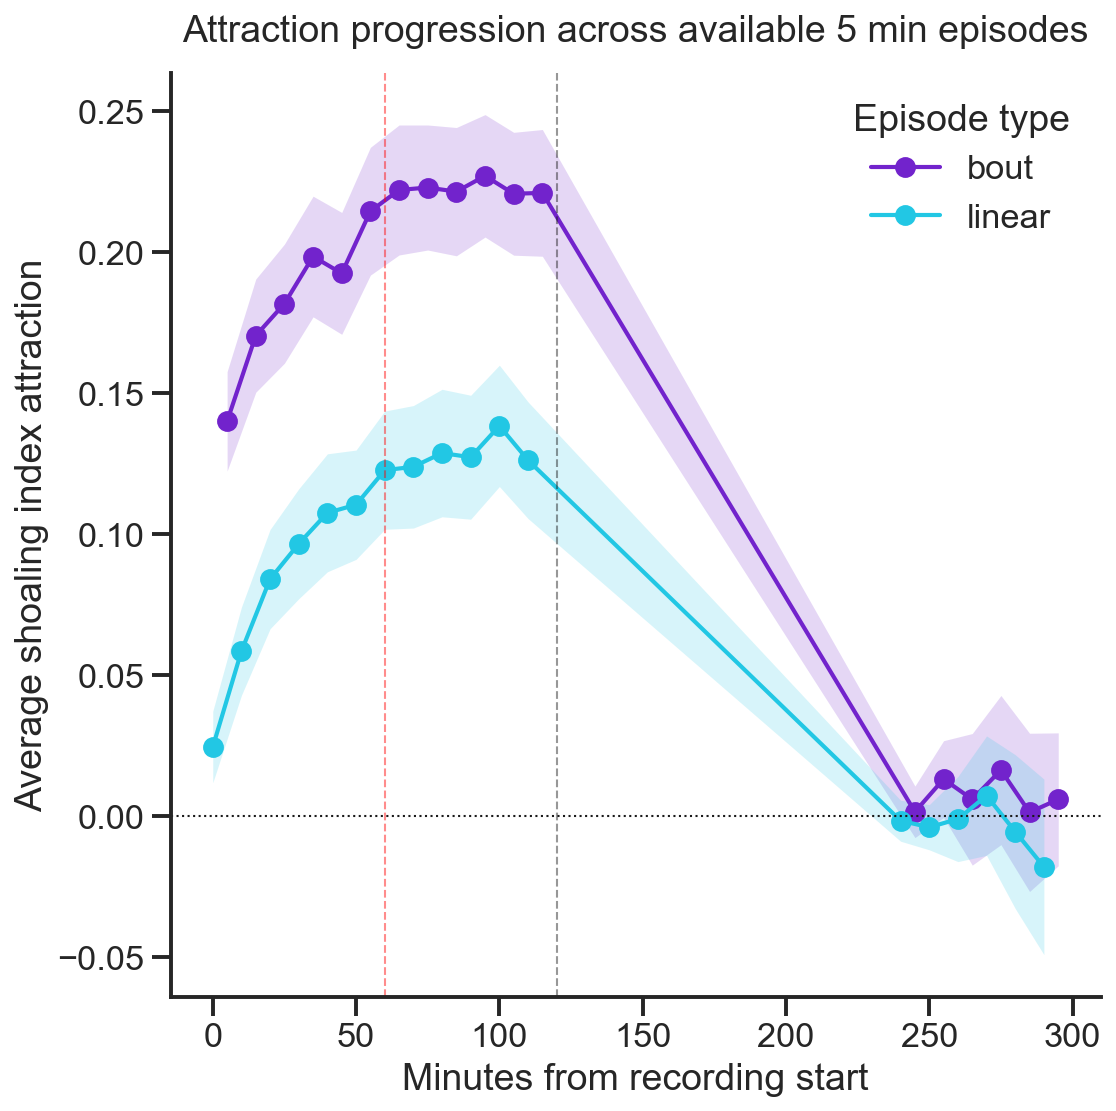

In [9]:
# Use only the full-window rows to visualize how attraction changes across the recording.
progression_source = df_plot.loc[df_plot['condition_key'] == FULL_CONDITION_KEY].copy()

# Average shoaling index by episode type and episode number, preserving the mean recording time for x-axis placement.
progression = (
    progression_source
    .groupby(['episode_type', 'episode_number'], as_index=False)
    .agg(
        recording_min=('recording_min', 'mean'),
        mean_si=('si', 'mean'),
        sem_si=('si', sem),
        ci95_si=('si', ci95),
        n=('si', 'size'),
    )
    .sort_values(['episode_type', 'episode_number'])
)

# Create one time-course plot with bout and linear episode types overlaid.
fig, ax = plt.subplots(figsize=(8, 8))

for episode_type, dat in progression.groupby('episode_type', sort=False):
    # Draw the mean trajectory and the selected uncertainty band for this episode type.
    color = EPISODE_PALETTE.get(episode_type, None)
    ax.plot(
        dat['recording_min'],
        dat['mean_si'],
        marker='o',
        linewidth=2,
        label=episode_type,
        color=color,
    )
    ax.fill_between(
        dat['recording_min'],
        dat['mean_si'] - dat[selected_uncertainty_column('si')],
        dat['mean_si'] + dat[selected_uncertainty_column('si')],
        alpha=SEM_BAND_ALPHA,
        color=color,
        linewidth=0,
    )

# Mark the first-24-episode cutoff used to define the 2h comparison window.
ax.axvline(REFERENCE_MINUTE, ls='--', color=MIDPOINT_REFERENCE_COLOR, alpha=REFERENCE_LINE_ALPHA, linewidth=1)
ax.axvline(EPISODES_2H * EPISODE_DURATION_MIN, ls='--', color=WINDOW_CUTOFF_COLOR, alpha=REFERENCE_LINE_ALPHA, linewidth=1)
#ax.text(EPISODES_2H * EPISODE_DURATION_MIN, ax.get_ylim()[1], ' 24 episodes', va='top', ha='left')
# Finish plot styling, save the PDF, and show the first rows of the summarized table.
ax.axhline(0, ls=':', color=ZERO_BASELINE_COLOR, linewidth=1)
ax.set_xlabel('Minutes from recording start')
ax.set_ylabel('Average shoaling index attraction')
ax.set_title('Attraction progression across available 5 min episodes', pad=15)
ax.legend(title='Episode type', frameon=False)
sns.despine()
fig.savefig(outputDir / 'attraction_progression_2026_4h_all.pdf', bbox_inches='tight')
progression.head()


### Combined 2h Progression Plot

Use only the first 24 five-minute episodes and plot the combined 2h time-course across experiments.

,episode_type,episode_number,recording_min,mean_si,sem_si,ci95_si,n
0,bout,2,5.0,0.140041,0.008949,0.017622,260
1,bout,4,15.0,0.170432,0.010190,0.020066,260
2,bout,6,25.0,0.181771,0.010721,0.021112,260
3,bout,8,35.0,0.198496,0.010861,0.021387,260
4,bout,10,45.0,0.192517,0.010970,0.021602,260


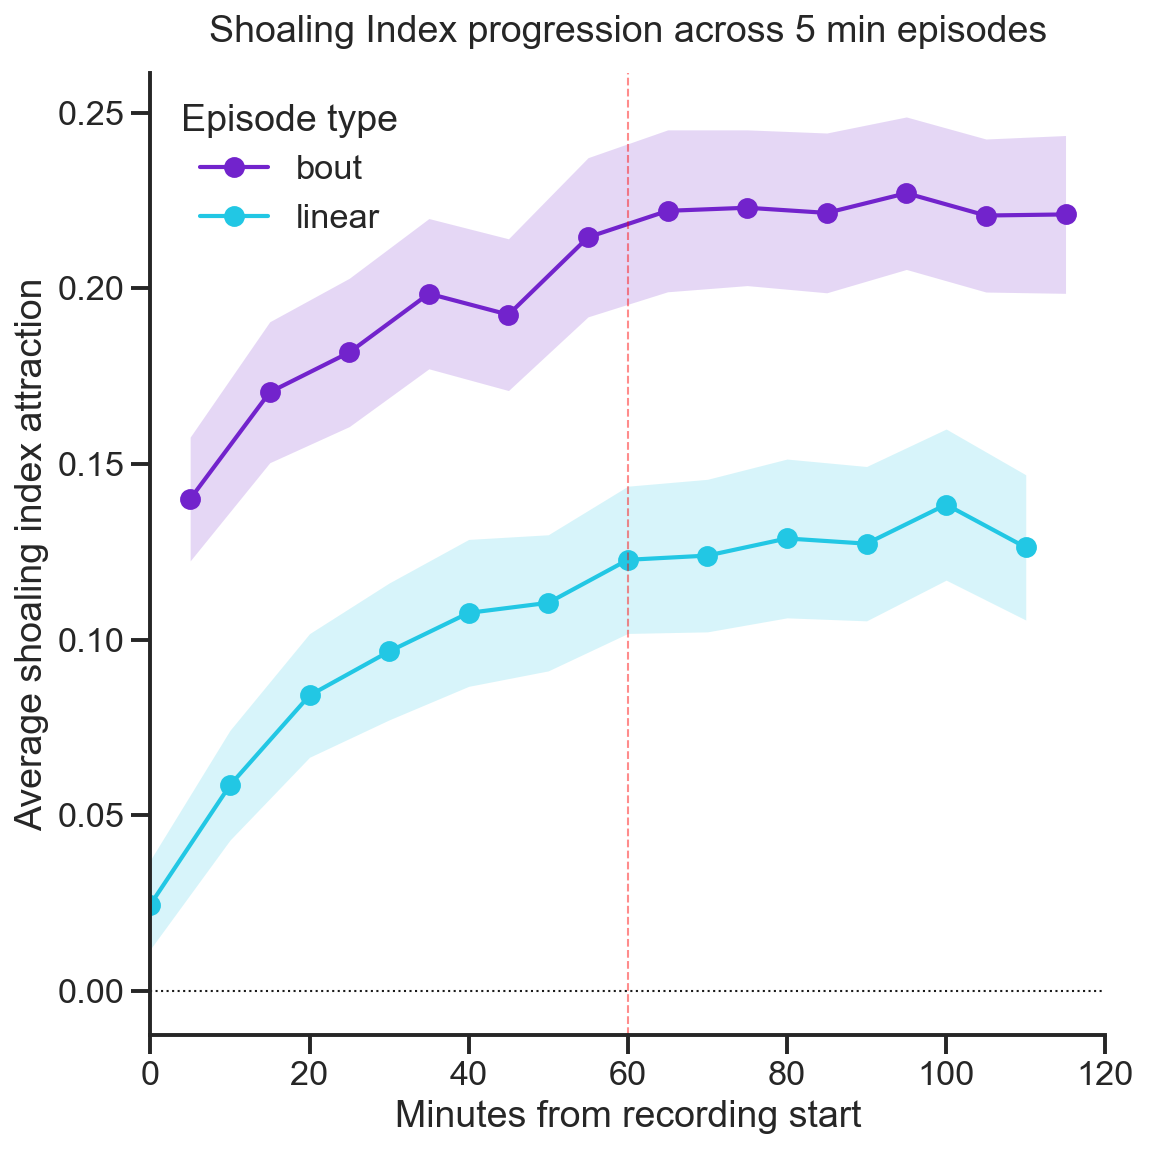

In [10]:
# Use only the derived 2h rows to visualize attraction across the 2h comparison window.
progression_2h_source = df_plot.loc[df_plot['condition_key'] == '2h'].copy()

# Average shoaling index by episode type and episode number, preserving the mean recording time for x-axis placement.
progression_2h = (
    progression_2h_source
    .groupby(['episode_type', 'episode_number'], as_index=False)
    .agg(
        recording_min=('recording_min', 'mean'),
        mean_si=('si', 'mean'),
        sem_si=('si', sem),
        ci95_si=('si', ci95),
        n=('si', 'size'),
    )
    .sort_values(['episode_type', 'episode_number'])
)

# Create one 2h time-course plot with bout and linear episode types overlaid.
fig, ax = plt.subplots(figsize=(8, 8))

for episode_type, dat in progression_2h.groupby('episode_type', sort=False):
    # Draw the mean trajectory and the selected uncertainty band for this episode type.
    color = EPISODE_PALETTE.get(episode_type, None)
    ax.plot(
        dat['recording_min'],
        dat['mean_si'],
        marker='o',
        linewidth=2,
        label=episode_type,
        color=color,
    )
    ax.fill_between(
        dat['recording_min'],
        dat['mean_si'] - dat[selected_uncertainty_column('si')],
        dat['mean_si'] + dat[selected_uncertainty_column('si')],
        alpha=SEM_BAND_ALPHA,
        color=color,
        linewidth=0,
    )

# Mark the one-hour midpoint and the end of the 2h comparison window.
ax.axvline(REFERENCE_MINUTE, ls='--', color=MIDPOINT_REFERENCE_COLOR, alpha=REFERENCE_LINE_ALPHA, linewidth=1)
#ax.axvline(EPISODES_2H * EPISODE_DURATION_MIN, ls='--', color=WINDOW_CUTOFF_COLOR, alpha=REFERENCE_LINE_ALPHA, linewidth=1)
#ax.text(EPISODES_2H * EPISODE_DURATION_MIN, ax.get_ylim()[1], ' 24 episodes', va='top', ha='left')
# Finish plot styling, save the PDF, and show the first rows of the summarized table.
ax.axhline(0, ls=':', color=ZERO_BASELINE_COLOR, linewidth=1)
ax.set_xlim(0, EPISODES_2H * EPISODE_DURATION_MIN)
ax.set_xlabel('Minutes from recording start')
ax.set_ylabel('Average shoaling index attraction')
ax.set_title('Shoaling Index progression across 5 min episodes', pad=15)
ax.legend(title='Episode type', frameon=False)
sns.despine()
plt.tight_layout()
fig.savefig(outputDir / 'attraction_progression_2026_2h.pdf', bbox_inches='tight')
progression_2h.head()


## 2h Progression By Experiment

Use only the first 24 five-minute episodes and plot one time-course panel per experiment. Bout and linear episodes are drawn on the same axes for each experiment.

,experiment_label,date_dt,setup,episode_type,episode_number,recording_min,mean_si,sem_si,ci95_si,n
48,Sel1_10.1_13-02-2026 setup 2,2026-02-13,2,bout,2,5.0,0.075347,0.013051,0.026553,35
49,Sel1_10.1_13-02-2026 setup 2,2026-02-13,2,bout,4,15.0,0.049695,0.020860,0.042441,35
50,Sel1_10.1_13-02-2026 setup 2,2026-02-13,2,bout,6,25.0,0.090260,0.019015,0.038687,35
51,Sel1_10.1_13-02-2026 setup 2,2026-02-13,2,bout,8,35.0,0.117670,0.024451,0.049745,35
52,Sel1_10.1_13-02-2026 setup 2,2026-02-13,2,bout,10,45.0,0.102231,0.022267,0.045302,35


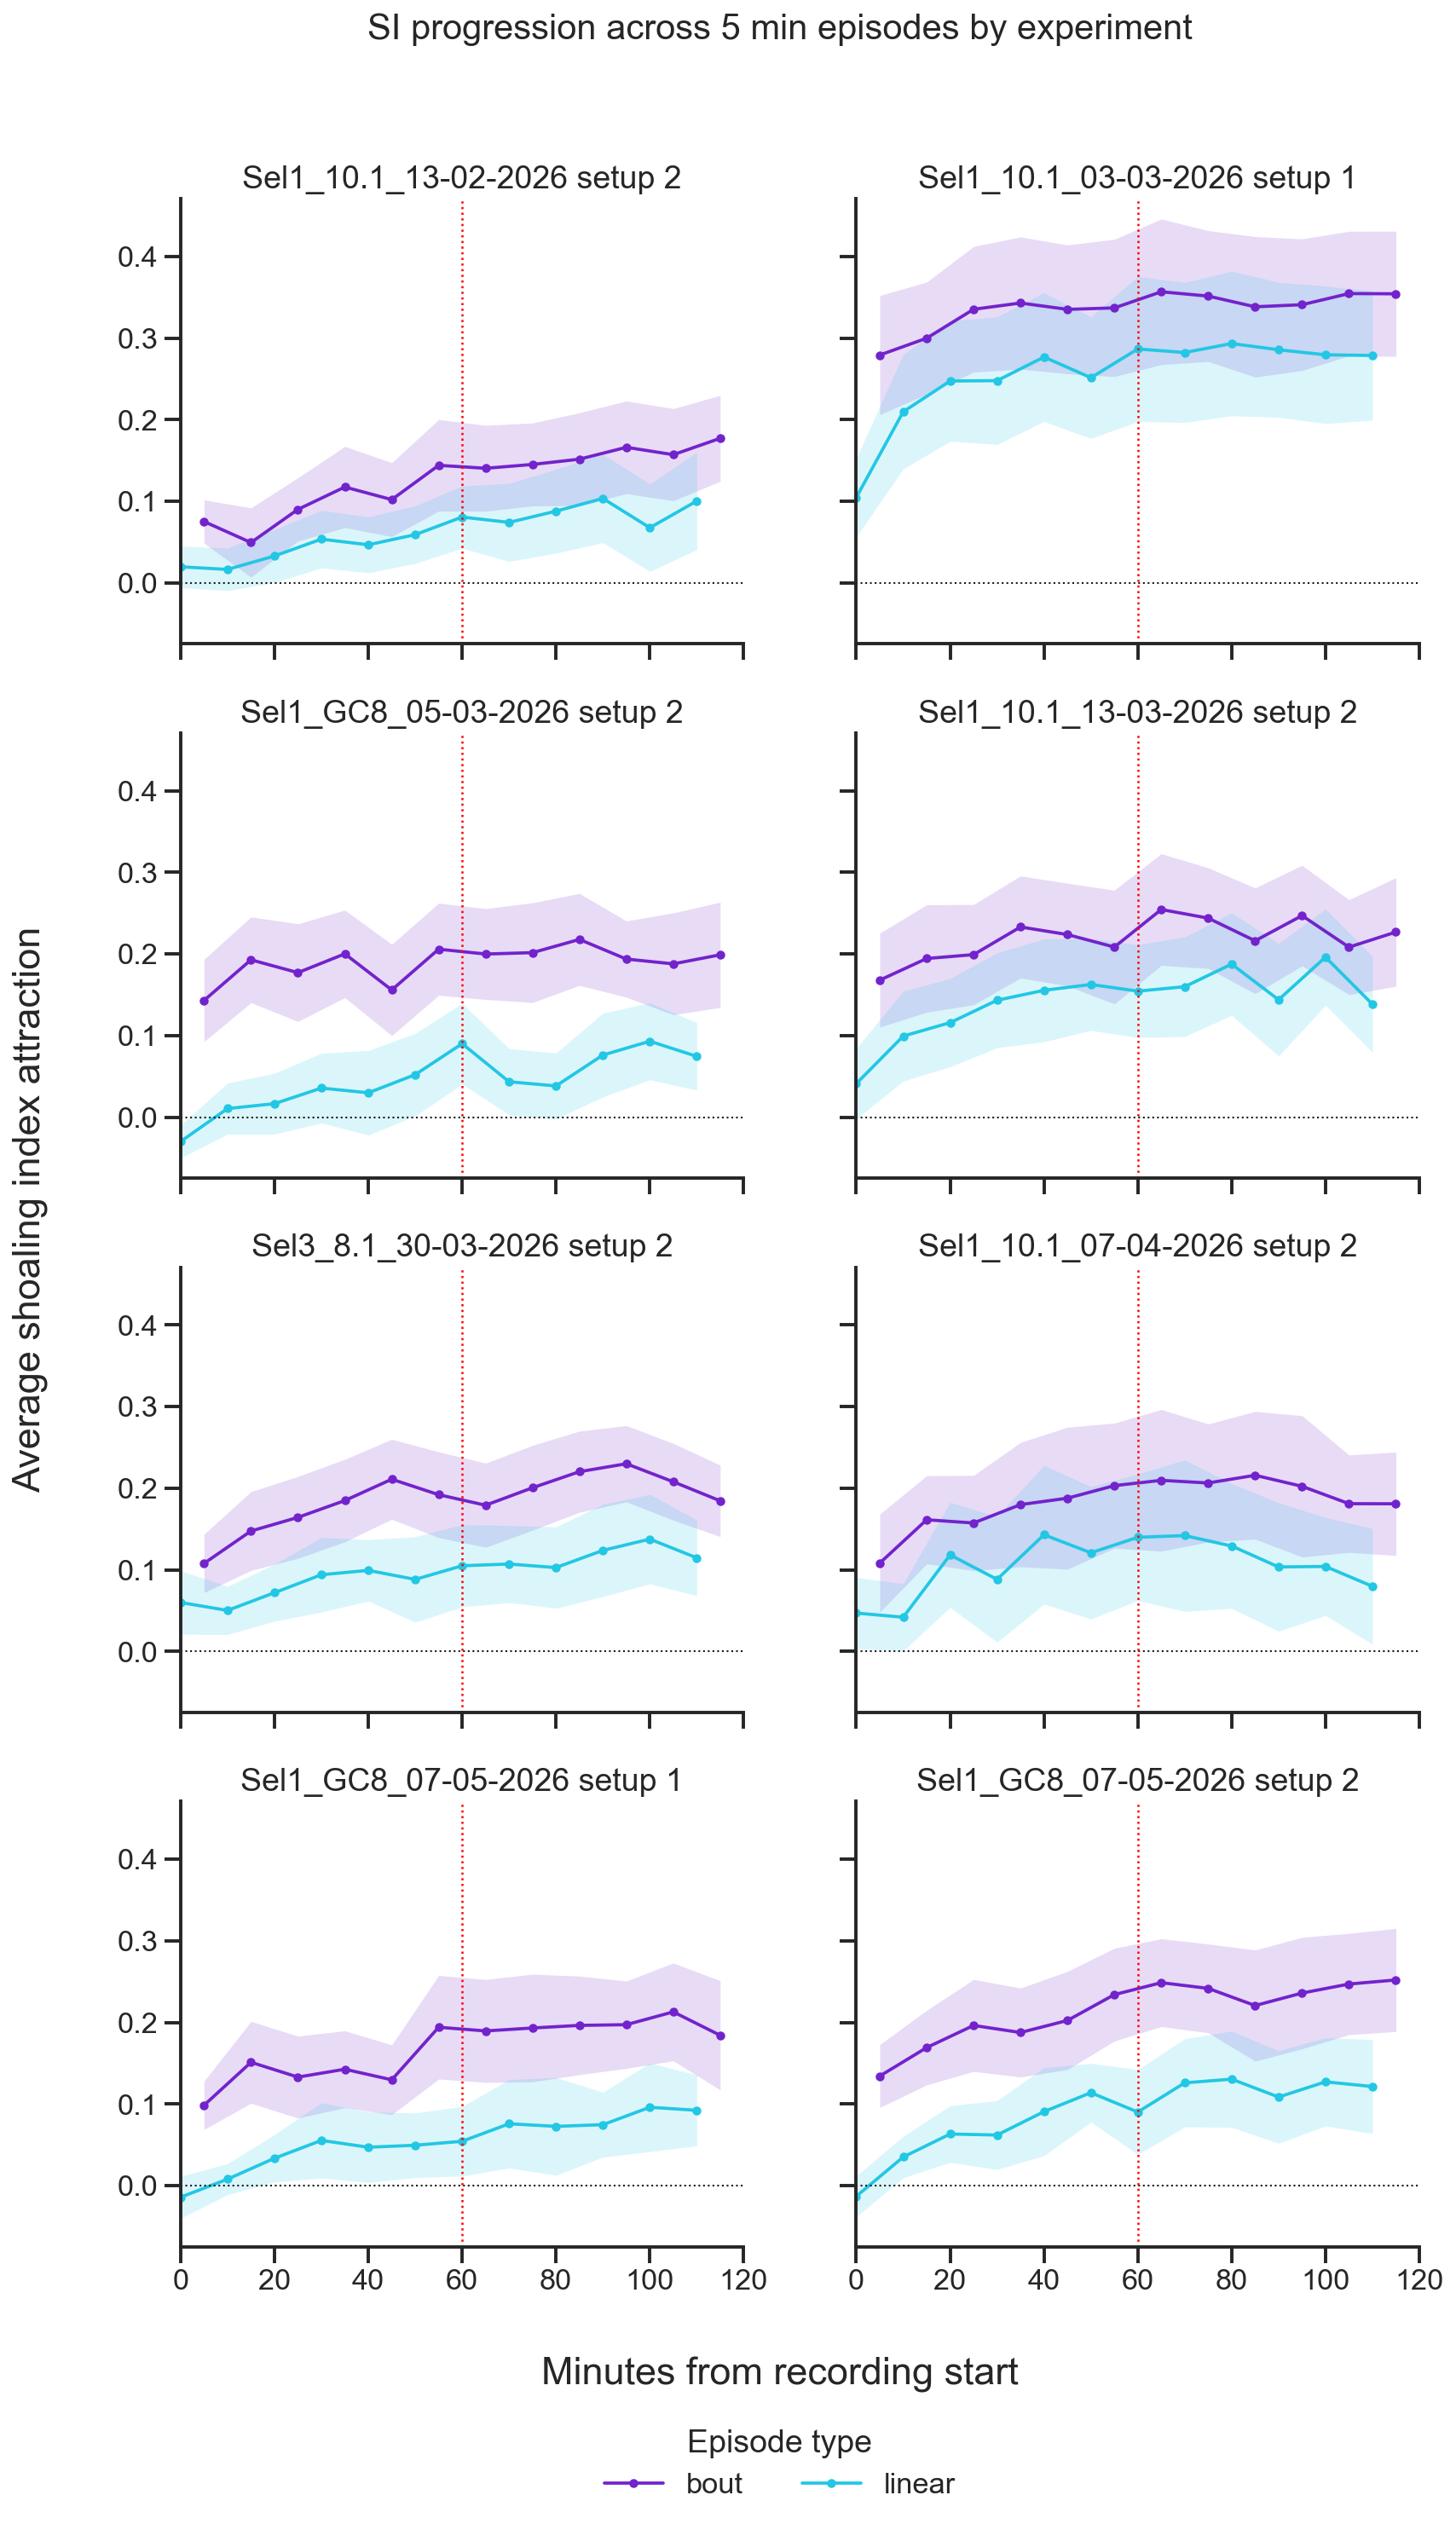

In [11]:
# Work from the derived 2h rows only; df_plot already excludes genotypes outside GENOTYPES.
progression_2h_source = df_plot.loc[df_plot['condition_key'] == '2h'].copy()

# The shared vertical reference marker uses REFERENCE_MINUTE and PER_EXPERIMENT_REFERENCE_LINE_STYLE from Settings.
# Build a readable panel label from the cohort/date label plus the recording setup.
progression_2h_source['experiment_label'] = (
    progression_2h_source['lineSet'].astype(str) + ' setup ' + progression_2h_source['setup'].astype(str)
)

# Collapse animal episode rows to one mean plus both uncertainty summaries per experiment, episode type, and 5-minute episode.
progression_2h_by_experiment = (
    progression_2h_source
    .groupby(['experiment_label', 'date_dt', 'setup', 'episode_type', 'episode_number'], as_index=False)
    .agg(
        recording_min=('recording_min', 'mean'),
        mean_si=('si', 'mean'),
        sem_si=('si', sem),
        ci95_si=('si', ci95),
        n=('si', 'size'),
    )
    .sort_values(['date_dt', 'setup', 'episode_type', 'episode_number'])
)

# Keep subplot order chronological, with setup as the tie-breaker when multiple rows share a date.
experiment_order = (
    progression_2h_by_experiment[['experiment_label', 'date_dt', 'setup']]
    .drop_duplicates()
    .sort_values(['date_dt', 'setup'])
)

# Build a compact two-column grid with shared axes so panels are visually comparable.
n_experiments = len(experiment_order)
ncols = 2
nrows = int(np.ceil(n_experiments / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(12.5, 5.2 * nrows), sharex=True, sharey=True)
axes = np.atleast_1d(axes).ravel()

# Draw one subplot per experiment; each subplot overlays bout and linear trajectories.
for ax, (_, experiment) in zip(axes, experiment_order.iterrows()):
    experiment_label = experiment['experiment_label']
    # Select only the summarized rows belonging to this panel's experiment label.
    experiment_dat = progression_2h_by_experiment.loc[
        progression_2h_by_experiment['experiment_label'] == experiment_label
    ]

    for episode_type, dat in experiment_dat.groupby('episode_type', sort=False):
        color = EPISODE_PALETTE.get(episode_type, None)
        # Mean shoaling-index trajectory for one episode type in this experiment.
        ax.plot(
            dat['recording_min'],
            dat['mean_si'],
            marker='o',
            linewidth=1.8,
            markersize=4,
            label=episode_type,
            color=color,
        )
        # Shaded band shows mean_si +/- the selected uncertainty half-width.
        ax.fill_between(
            dat['recording_min'],
            dat['mean_si'] - dat[selected_uncertainty_column('si')],
            dat['mean_si'] + dat[selected_uncertainty_column('si')],
            alpha=PER_EXPERIMENT_SEM_BAND_ALPHA,
            color=color,
            linewidth=0,
        )

    # Add the zero baseline and the editable vertical time marker to every visible panel.
    ax.axhline(0, ls=':', color=ZERO_BASELINE_COLOR, linewidth=1)
    ax.axvline(REFERENCE_MINUTE, **PER_EXPERIMENT_REFERENCE_LINE_STYLE)
    ax.set_title(experiment_label)

# Hide unused axes when the experiment count does not fill the last grid row.
for ax in axes[n_experiments:]:
    ax.set_visible(False)

# Limit the shared x-axis to the 2h window: 24 episodes x 5 minutes.
for ax in axes[:n_experiments]:
    ax.set_xlim(0, EPISODES_2H * EPISODE_DURATION_MIN)

# Use one shared legend and figure-level labels instead of repeating them in every panel.
handles, labels = axes[0].get_legend_handles_labels()

fig.supxlabel('Minutes from recording start', y=0.055)
fig.supylabel('Average shoaling index attraction')

fig.legend(
    handles,
    labels,
    title='Episode type',
    frameon=False,
    loc='lower center',
    bbox_to_anchor=(0.5, 0.005),
    ncol=2,
)

fig.suptitle('SI progression across 5 min episodes by experiment', fontsize = 20,y=0.95)
sns.despine(fig=fig)
#plt.tight_layout(rect=(0, 0.10, 1, 0.98))
# handles, labels = axes[0].get_legend_handles_labels()
# fig.legend(handles, labels, title='Episode type', frameon=False, loc='lower center', bbox_to_anchor=(0.5, 0.035), ncol=2,)
# fig.supxlabel('Minutes from recording start')
# fig.supylabel('Average shoaling index attraction')
# fig.suptitle('SI progression across 5 min episodes by experiment', fontsize = 20, y=0.93)
# sns.despine(fig=fig)
# #plt.tight_layout(rect=(0, 0.07, 1, 0.96))
# Save the figure and display the first summarized rows as a quick data check.
fig.savefig(outputDir / 'attraction_progression_2026_2h_by_experiment.pdf', bbox_inches='tight')
progression_2h_by_experiment.head()


## 2h SI slowdown inference

### Question and definition

This section asks when the SI progression has slowed enough that the **next fitted increase for the same stimulus** is practically small. It uses only the first 24 five-minute episodes (the 2-hour window) and analyzes bout-like and linear stimuli separately. Because those stimuli alternate, consecutive observations of one stimulus are normally 10 minutes apart.

For stimulus $s$, let $m_s(t)$ be its fitted cohort-average SI at exposure time $t$. For every pair of consecutive same-stimulus exposures, the plotted fraction is

$$r_s(t) = \frac{m_s(t_{next}) - m_s(t)}{m_s(t_{last}) - m_s(t_{first})}. $$

The denominator is the fitted first-to-last SI increase for that stimulus within this 2-hour window. With `SI_SLOWDOWN_FRACTION = 0.05`, an interval is practically small when its next fitted increase is below 5% of that total increase. This is a relative threshold, not 0.05 SI units. The crossing must also be **persistent**: the fraction at the candidate time and every later available fraction must remain below the threshold. A temporary early dip therefore does not count.

The x-value belongs to the **start of the forward comparison**. For example, the linear point at x = 100 compares fitted SI at 100 minutes with fitted SI at the next linear exposure, normally 110 minutes.

### Model and uncertainty

The primary natural-cubic-spline mixed model is fitted to the original fish-by-episode rows, never to the displayed episode means. It includes genotype as a fixed effect, an experiment random intercept, and a fish-within-experiment variance component. The plotted fitted curve averages genotype-specific predictions using the observed fish-level genotype proportions. Separate models allow the two stimuli to have different curve shapes.

The **fitted slowdown** is the first persistent crossing of the fitted fractions. It is descriptive. The bootstrap adds uncertainty while respecting the experiment/fish/time hierarchy.

### Bootstrap procedure, step by step (Note: We probably have too few experiments for this method. I will think of a good substitute but I will leave it for now - CR)

The bootstrap is run **separately for each stimulus**. With 500 requested draws and two stimuli, the default analysis attempts 500 bout-model refits and 500 linear-model refits. The random-number generator continues across stimuli, so their resampling sequences are reproducible from one seed but are not paired draw-for-draw.

1. Suppose one stimulus contains $E$ experiments. A bootstrap draw samples exactly $E$ experiment IDs **with replacement** from those $E$ experiments. For example, a draw from experiments A, B, C, D might be A, A, C, D: B is absent and A contributes two complete copies.
2. Every selected copy retains all of that experiment's fish and all of their episode rows. The code does not resample individual fish, episodes, or residuals. This preserves dependence among fish from the same experiment and repeated observations from the same fish—the experiment is treated as the highest independent sampling unit.
3. If an experiment is selected more than once, its copies receive new bootstrap experiment IDs such as `boot_0` and `boot_1`; fish IDs are rebuilt under those new IDs. The mixed model can therefore treat repeated selections as separate bootstrap clusters rather than accidentally merging identical copies into one group.
4. The same spline mixed model is refitted to the resampled rows and evaluated on the original stimulus-specific exposure-time grid. Genotype weights are recalculated from the resampled fish, so the bootstrap also reflects experiment-to-experiment changes in cohort genotype composition.
5. From each successful refit, the code records the bootstrap total increase. A draw contributes an interval-fraction curve only when its total increase is positive and every fraction is finite. Model-fit failures are skipped; successfully fitted nonpositive totals remain in the total-increase distribution but cannot define meaningful normalized fractions.
6. For every usable positive-total curve, the same persistent-crossing rule is applied. A draw can be usable yet have no crossing because one or more late fractions never stay below 5%; its crossing time is stored as missing.

The validity summaries use the number of **requested** draws as their denominator. `bootstrap_valid_rate` is the fraction yielding usable positive-total fraction curves. `bootstrap_crossing_rate` is the fraction yielding a finite descriptive crossing, so it can be lower than the valid rate. With `SI_SLOWDOWN_MIN_BOOTSTRAP_VALID = 0.80`, at least 400 of 500 requested draws must be usable.

### Positive-increase gate

Before interpreting slowdown fractions, the analysis requires evidence that there was a positive SI increase to slow down. For 95% confidence it takes the 5th percentile of the successfully fitted bootstrap total increases as a one-sided lower bound. Uncertainty-supported inference is enabled only if (i) the original fitted total is positive, (ii) bootstrapping ran, (iii) the valid rate meets the 80% minimum, and (iv) this lower bound is above zero. If any gate fails, the result table reports the reason in `inference_status` and suppresses the inferential crossing fields.

### Two different uses of the bootstrap

**1. Descriptive crossing-time interval.** Among usable draws that actually produce a finite persistent crossing, the 2.5th and 97.5th percentiles give `fitted_slowdown_ci_low_min` and `fitted_slowdown_ci_high_min`. This is conditional on a crossing existing; it does not count no-crossing draws as later than the recording window. It must therefore be read with `bootstrap_crossing_rate`. A narrow conditional interval is not strong evidence if crossings occur in only a small fraction of requested draws.

**2. Simultaneous one-sided upper band.** Let $\hat r_j$ be the original fitted fraction at interval $j$ and $r^*_{bj}$ the fraction in usable bootstrap draw $b$. Each draw is reduced to its largest signed upward deviation anywhere on the curve,

$$D_b = \max_j \left(r^*_{bj} - \hat r_j\right).$$

The 95th percentile of the $D_b$ values is one critical value $c_{0.95}$, and the plotted dotted upper band is

$$U_j = \hat r_j + c_{0.95}.$$

Using the maximum deviation makes this a whole-curve simultaneous band rather than a collection of pointwise 95% bounds. The **uncertainty-supported slowdown** is the first interval for which $U_j < 0.05$ and every later $U$ value also remains below 0.05. It is consequently at least as conservative as the fitted crossing and can be absent within the observed window.

The independent-information count for this bootstrap is primarily the number of experiments, not the much larger number of fish-by-episode rows. With few experiments, cluster-bootstrap estimates can be discrete or unstable; changing the seed or increasing the number of draws assesses Monte Carlo stability but cannot create additional independent experiments. Also note that a candidate at the last plotted interval has only that final forward increment left to satisfy the persistence rule, which is why late-window coverage and leave-one-experiment-out results remain important.

### How to read the figure

- Purple denotes bout-like stimuli and cyan denotes linear stimuli.
- The upper panel shows observed means with the selected SEM/95% CI and the mixed-model marginal fits.
- The lower solid-with-markers curves are fitted forward-increment fractions; dotted curves are their simultaneous one-sided upper bounds; the horizontal dashed line is the editable 5% threshold.
- **Dashed vertical lines** mark descriptive fitted slowdowns. **Solid vertical lines** mark uncertainty-supported slowdowns. Thus the solid cyan line at 100 minutes means that, for the linear stimulus, 100 minutes is the first interval start from which the 95% simultaneous upper bound remains below 5% for every remaining same-stimulus increment. It does not mark a recording cutoff, curve maximum, or raw observation.
- A stimulus with a dashed line but no solid line has a descriptive crossing but no uncertainty-supported crossing inside the 2-hour window.

### Output guide

| Field or table | Interpretation |
| --- | --- |
| `fitted_slowdown_min` | Descriptive first persistent crossing of the fitted fraction; plotted as a dashed vertical line. |
| `fitted_slowdown_ci_low_min`, `fitted_slowdown_ci_high_min` | Bootstrap interval for the descriptive crossing, conditional on bootstrap draws that produced a finite crossing. Read it together with `bootstrap_crossing_rate`. |
| `supported_slowdown_min` | First persistent crossing of the simultaneous upper band; plotted as a solid vertical line. `NaN` means the criterion was not supported inside the window. |
| `total_fitted_increase` | Fitted SI at the last same-stimulus exposure minus fitted SI at the first. |
| `threshold_increment` | The 5% threshold converted back to raw SI units for that stimulus (`fraction * total_fitted_increase`). |
| `bootstrap_valid_rate` | Requested bootstrap fraction yielding usable positive-total increment curves. |
| `bootstrap_crossing_rate` | Requested bootstrap fraction yielding a finite descriptive crossing. |
| `increase_supported`, `inference_status` | Gate and reason indicating whether uncertainty-supported slowdown inference was valid. |
| `asymptotic_*`, `model_dependent` | Comparison with the optional saturating-exponential curve; this is a sensitivity result, not the primary estimate. |
| `si_slowdown_curve` | Exact forward intervals, fitted SI values, fractions, and simultaneous upper band used in the figure. |
| diagnostics and coverage | Median within-fish lag-1 residual correlation and counts of observations, fish, and experiments at each exposure. |
| spline sensitivity and leave-one-out | Whether the descriptive crossing changes with spline flexibility or omission of one experiment. |

These checks should be interpreted alongside the headline crossing: strong residual serial structure, late-window attrition, or large sensitivity shifts weaken a simple single-time summary.

In [12]:
# Analyze exactly the 2-hour window. df_plot contains both the derived 2h condition and the full recording,
# so filter both condition_key and episode_number to make accidental full-window inference impossible.
progression_2h_source = df_plot.loc[
    (df_plot['condition_key'] == '2h')
    & (df_plot['episode_number'] <= EPISODES_2H)
].copy()
assert progression_2h_source['episode_number'].max() <= EPISODES_2H

# This grouped table is display-only: its means and SEM/CI become points and error bars in the upper panel.
# The inferential model below still receives every original fish-by-episode row in progression_2h_source.
progression_2h = (
    progression_2h_source
    .groupby(['episode_type', 'episode_number'], as_index=False)
    .agg(
        recording_min=('recording_min', 'mean'),
        mean_si=('si', 'mean'),
        sem_si=('si', sem),
        ci95_si=('si', ci95),
        n=('si', 'size'),
    )
    .sort_values(['episode_type', 'episode_number'])
)

# Fit one spline mixed model per stimulus and run an experiment-cluster bootstrap. The helper returns
# interval-level fitted fractions as well as headline crossings and diagnostic/sensitivity tables.
si_slowdown = sis.estimate_si_slowdown(
    progression_2h_source,
    fraction=SI_SLOWDOWN_FRACTION,
    confidence=SI_SLOWDOWN_CONFIDENCE,
    spline_df=SI_SLOWDOWN_SPLINE_DF,
    n_boot=SI_SLOWDOWN_BOOTSTRAPS,
    random_state=SI_SLOWDOWN_RANDOM_SEED,
    min_bootstrap_valid=SI_SLOWDOWN_MIN_BOOTSTRAP_VALID,
    sensitivity_spline_dfs=SI_SLOWDOWN_SENSITIVITY_DF,
    run_leave_one_experiment_out=SI_SLOWDOWN_RUN_LEAVE_ONE_EXPERIMENT_OUT,
    run_asymptotic_sensitivity=SI_SLOWDOWN_RUN_ASYMPTOTIC_SENSITIVITY,
    progress_every=SI_SLOWDOWN_PROGRESS_EVERY,
)

# One results row per stimulus: fitted_slowdown_* is descriptive, whereas supported_slowdown_*
# requires the simultaneous upper band to stay below the threshold at that interval and thereafter.
si_slowdown_results = si_slowdown.results.copy()
# One curve row per forward interval. recording_min -> next_recording_min identifies the exact
# same-stimulus comparison represented by increment_fraction and simultaneous_upper_fraction.
si_slowdown_curve = si_slowdown.curve.copy()

# Save notebook-specific inference and diagnostic tables without changing canonical SI summaries.
# The curve CSV reproduces the lower panel; coverage exposes late-window sample loss; residual
# diagnostics, spline sensitivity, and leave-one-out fits qualify interpretation of the crossings.
si_slowdown_results.to_csv(outputDir / 'si_slowdown_results_2026_2h.csv', index=False)
si_slowdown_curve.to_csv(outputDir / 'si_slowdown_curve_2026_2h.csv', index=False)
si_slowdown.diagnostics.to_csv(outputDir / 'si_slowdown_residual_diagnostics_2026_2h.csv', index=False)
si_slowdown.coverage.to_csv(outputDir / 'si_slowdown_episode_coverage_2026_2h.csv', index=False)
si_slowdown.spline_sensitivity.to_csv(outputDir / 'si_slowdown_spline_sensitivity_2026_2h.csv', index=False)
si_slowdown.leave_one_experiment_out.to_csv(outputDir / 'si_slowdown_leave_one_out_2026_2h.csv', index=False)

# Display the headline result first, followed by checks for residual dependence and model sensitivity.
display(si_slowdown_results)
display(si_slowdown.diagnostics)
display(si_slowdown.spline_sensitivity)
display(si_slowdown.leave_one_experiment_out)


,stimulus_type,fitted_slowdown_episode,fitted_slowdown_min,fitted_slowdown_ci_low_min,fitted_slowdown_ci_high_min,supported_slowdown_episode,supported_slowdown_min,total_fitted_increase,total_increase_one_sided_lower,threshold_increment,slowdown_fraction,bootstrap_valid_rate,bootstrap_crossing_rate,increase_supported,inference_status,asymptotic_slowdown_episode,asymptotic_slowdown_min,asymptotic_tau_min,model_dependent
0,bout,NaN,NaN,NaN,NaN,NaN,NaN,0.075216,NaN,0.003761,0.05,NaN,NaN,False,bootstrap_not_run,14.0,65.0,29.332939,False
1,linear,NaN,NaN,NaN,NaN,NaN,NaN,0.102440,NaN,0.005122,0.05,NaN,NaN,False,bootstrap_not_run,13.0,60.0,27.536120,False


,stimulus_type,median_fish_residual_lag1,n_fish_with_lag1
0,bout,0.054146,259
1,linear,0.119485,259


,stimulus_type,spline_df,total_fitted_increase,fitted_slowdown_episode,fitted_slowdown_min,is_primary_model
0,bout,4,0.075216,16.0,75.0,True
1,bout,3,0.074496,14.0,65.0,False
2,bout,5,0.079443,16.0,75.0,False
3,bout,6,0.079827,14.0,65.0,False
4,linear,4,0.102440,17.0,80.0,True
5,linear,3,0.101622,11.0,50.0,False
6,linear,5,0.104257,15.0,70.0,False
7,linear,6,0.104127,13.0,60.0,False


,stimulus_type,omitted_experiment,total_fitted_increase,fitted_slowdown_episode,fitted_slowdown_min
0,bout,0,0.069700,16.0,75.0
1,bout,1,0.075275,16.0,75.0
2,bout,2,0.081789,16.0,75.0
3,bout,3,0.079293,16.0,75.0
4,bout,4,0.074152,14.0,65.0
5,bout,5,0.076614,16.0,75.0
6,bout,6,0.075067,16.0,75.0
7,bout,7,0.069763,18.0,85.0
8,linear,0,0.106662,15.0,70.0
9,linear,1,0.095433,15.0,70.0


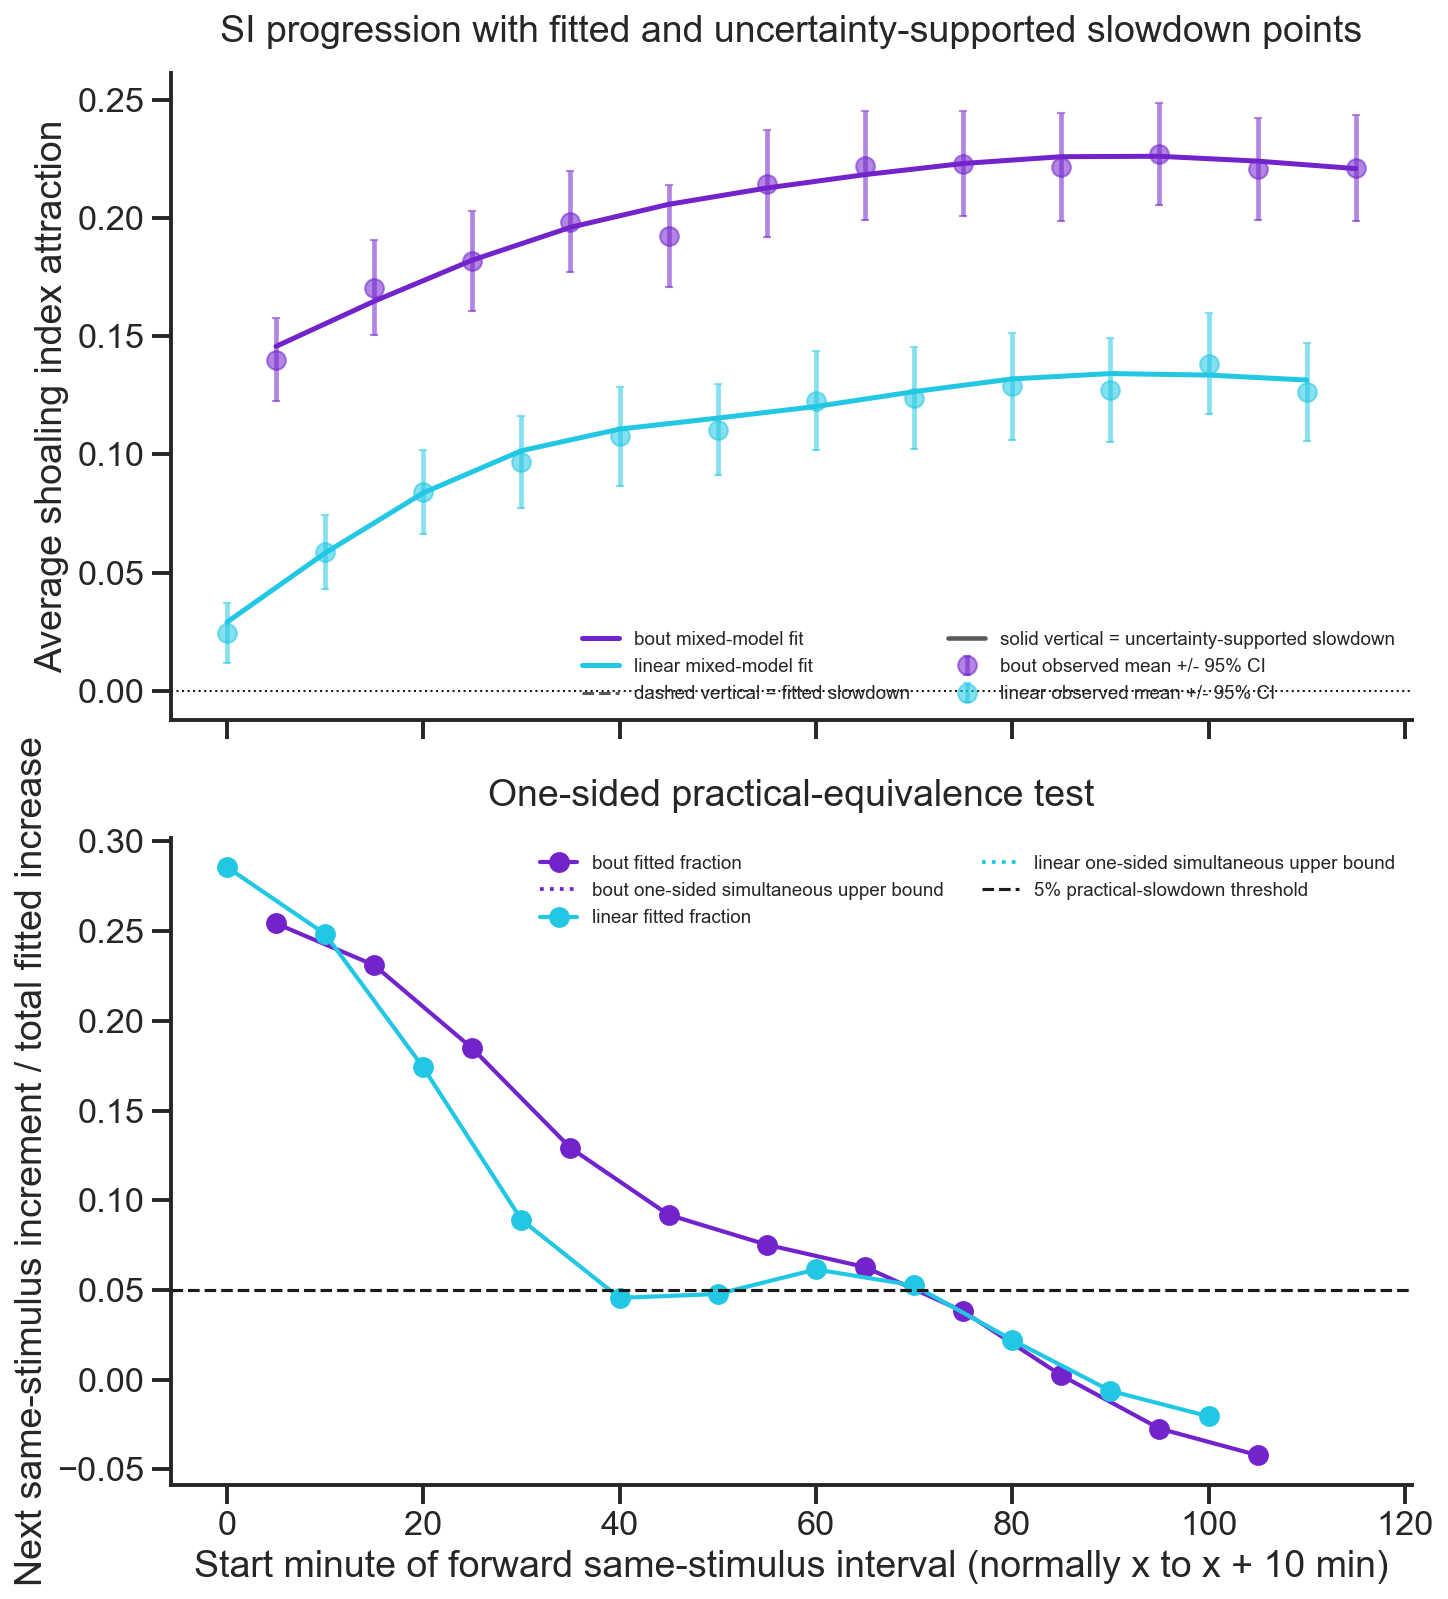

In [13]:
# Upper panel: observed SI summaries and model fits. Lower panel: the actual forward-increment
# statistic used by the practical-equivalence test and its simultaneous uncertainty bound.
fig, (ax_si, ax_fraction) = plt.subplots(2, 1, figsize=(10, 11), sharex=True)

for stimulus_type, dat in si_slowdown_curve.groupby('stimulus_type', sort=False):
    color = EPISODE_PALETTE.get(stimulus_type)
    # Observed points are visual summaries only; the fitted line comes from raw fish-level rows.
    observed = progression_2h.loc[progression_2h['episode_type'] == stimulus_type]
    ax_si.errorbar(
        observed['recording_min'],
        observed['mean_si'],
        yerr=observed[selected_uncertainty_column('si')],
        fmt='o',
        color=color,
        alpha=0.55,
        capsize=2,
        label=f'{stimulus_type} observed mean +/- {PLOT_UNCERTAINTY_LABEL}',
    )
    # curve has one row per interval and therefore omits the final endpoint as a row start; append
    # that endpoint here so the upper-panel fitted SI line reaches the last observed exposure.
    fitted_times = np.append(dat['recording_min'].to_numpy(), dat['next_recording_min'].iloc[-1])
    fitted_values = np.append(dat['fitted_si'].to_numpy(), dat['next_fitted_si'].iloc[-1])
    ax_si.plot(fitted_times, fitted_values, color=color, linewidth=2.4, label=f'{stimulus_type} mixed-model fit')

    # Each marker at x represents the fitted change from x to next_recording_min, divided by the
    # stimulus-specific fitted first-to-last increase over the complete 2-hour analysis window.
    ax_fraction.plot(
        dat['recording_min'],
        dat['increment_fraction'],
        marker='o',
        color=color,
        linewidth=2,
        label=f'{stimulus_type} fitted fraction',
    )
    # This is a simultaneous (whole-curve) one-sided upper band, not a pointwise error bar.
    ax_fraction.plot(
        dat['recording_min'],
        dat['simultaneous_upper_fraction'],
        color=color,
        linestyle=':',
        linewidth=1.8,
        label=f'{stimulus_type} one-sided simultaneous upper bound',
    )

    # Dashed vertical = first persistent crossing of the fitted fraction (descriptive only).
    # Solid vertical = first persistent crossing of the upper band (uncertainty-supported).
    # Line color retains stimulus identity. A missing solid line means support was not reached.
    result = si_slowdown_results.loc[si_slowdown_results['stimulus_type'] == stimulus_type].iloc[0]
    if np.isfinite(result['fitted_slowdown_min']):
        ax_si.axvline(result['fitted_slowdown_min'], color=color, linestyle='--', linewidth=1.5)
        ax_fraction.axvline(result['fitted_slowdown_min'], color=color, linestyle='--', linewidth=1.5)
    if np.isfinite(result['supported_slowdown_min']):
        ax_si.axvline(result['supported_slowdown_min'], color=color, linestyle='-', linewidth=2.2)
        ax_fraction.axvline(result['supported_slowdown_min'], color=color, linestyle='-', linewidth=2.2)

# Add explicit style keys because the colored vertical lines otherwise have no legend entries.
# Empty plots create legend handles without adding data to either axis.
ax_si.plot([], [], color='0.35', linestyle='--', linewidth=1.5, label='dashed vertical = fitted slowdown')
ax_si.plot([], [], color='0.35', linestyle='-', linewidth=2.2, label='solid vertical = uncertainty-supported slowdown')

ax_si.axhline(0, ls=':', color=ZERO_BASELINE_COLOR, linewidth=1)
ax_si.set_ylabel('Average shoaling index attraction')
ax_si.set_title('SI progression with fitted and uncertainty-supported slowdown points', pad=15)
ax_si.legend(frameon=False, fontsize=9, ncol=2)

# The threshold is a fraction of fitted first-to-last increase, not an SI-unit threshold.
ax_fraction.axhline(SI_SLOWDOWN_FRACTION, color=WINDOW_CUTOFF_COLOR, linestyle='--', linewidth=1.5, label=f'{SI_SLOWDOWN_FRACTION:.0%} practical-slowdown threshold')
ax_fraction.set_xlabel('Start minute of forward same-stimulus interval (normally x to x + 10 min)')
ax_fraction.set_ylabel('Next same-stimulus increment / total fitted increase')
ax_fraction.set_title('One-sided practical-equivalence test', pad=15)
ax_fraction.legend(frameon=False, fontsize=9, ncol=2)
sns.despine(fig=fig)
fig.tight_layout()
fig.savefig(outputDir / 'si_slowdown_progression_2026_2h.pdf', bbox_inches='tight')
plt.show()


## Maximum-Normalized SI Progression

Express every SI observation as a percentage of that fish's own positive maximum for the same stimulus type. Invalid fish/type combinations are excluded independently, and all valid fish are pooled at each 5-minute episode position.

In [14]:
# Keep the established episode codes while using consistent display labels for this analysis.
SI_NORMALIZED_EPISODE_LABELS = {'linear': 'continuous', 'bout': 'bout-like'}
SI_NORMALIZED_EPISODE_ORDER = ['continuous', 'bout-like']
SI_NORMALIZED_EPISODE_PALETTE = {
    'continuous': EPISODE_PALETTE['linear'],
    'bout-like': EPISODE_PALETTE['bout'],
}

# Work only from the first 2 h and identify experiments with the stable processing-set key.
si_change_animal = df_plot.loc[
    (df_plot['condition_key'] == '2h')
    & df_plot['episode_type'].isin(SI_NORMALIZED_EPISODE_LABELS)
].copy()
si_change_animal['episode_type_display'] = si_change_animal['episode_type'].map(SI_NORMALIZED_EPISODE_LABELS)
si_change_animal['experiment_label'] = (
    si_change_animal['lineSet'].astype(str) + ' setup ' + si_change_animal['setup'].astype(str)
)

# Give each fish separate continuous and bout-like denominators from its own maximum SI.
si_max_by_fish_type = (
    si_change_animal
    .groupby(['animalSet', 'animalIndex', 'episode_type'], as_index=False)
    .agg(max_fish_type_si=('si', 'max'))
)
excluded_si_fish_types = si_max_by_fish_type.loc[
    ~np.isfinite(si_max_by_fish_type['max_fish_type_si'])
    | (si_max_by_fish_type['max_fish_type_si'] <= 0)
].copy()
if not excluded_si_fish_types.empty:
    print(
        f'Excluding {len(excluded_si_fish_types)} fish/stimulus combinations '
        'with no finite positive maximum SI:'
    )
    print(excluded_si_fish_types.to_string(index=False))

# Keep a fish in its other stimulus category when only one category has an invalid maximum.
si_max_by_fish_type = si_max_by_fish_type.loc[
    np.isfinite(si_max_by_fish_type['max_fish_type_si'])
    & (si_max_by_fish_type['max_fish_type_si'] > 0)
].copy()

si_change_animal = si_change_animal.merge(
    si_max_by_fish_type,
    on=['animalSet', 'animalIndex', 'episode_type'],
    how='inner',
    validate='many_to_one',
)
si_change_animal['si_pct_fish_max'] = (
    100 * si_change_animal['si'] / si_change_animal['max_fish_type_si']
)

# Pool all valid fish at each episode position, matching the original SI progression hierarchy.
si_normalized_all_fish = (
    si_change_animal
    .groupby(['episode_type_display', 'episode_number'], as_index=False)
    .agg(
        recording_min=('recording_min', 'mean'),
        mean_si_pct_fish_max=('si_pct_fish_max', 'mean'),
        sem_si_pct_fish_max=('si_pct_fish_max', sem),
        ci95_si_pct_fish_max=('si_pct_fish_max', ci95),
        n_fish=('si_pct_fish_max', 'size'),
    )
    .sort_values(['episode_type_display', 'episode_number'])
)

# Build the same normalized summary within each experiment for the grid.
si_normalized_by_experiment = (
    si_change_animal
    .groupby(
        [
            'animalSet', 'experiment_label', 'date_dt', 'setup',
            'episode_type_display', 'episode_number',
        ],
        as_index=False,
    )
    .agg(
        recording_min=('recording_min', 'mean'),
        mean_si_pct_fish_max=('si_pct_fish_max', 'mean'),
        sem_si_pct_fish_max=('si_pct_fish_max', sem),
        ci95_si_pct_fish_max=('si_pct_fish_max', ci95),
        n_fish=('si_pct_fish_max', 'size'),
    )
    .sort_values(['date_dt', 'setup', 'episode_type_display', 'episode_number'])
)

si_normalized_all_fish.head()


Excluding 3 fish/stimulus combinations with no finite positive maximum SI:
 animalSet  animalIndex episode_type  max_fish_type_si
         0          805         bout               NaN
         0          805       linear               NaN
         1          823       linear         -0.007577


,episode_type_display,episode_number,recording_min,mean_si_pct_fish_max,sem_si_pct_fish_max,ci95_si_pct_fish_max,n_fish
0,bout-like,2,5.0,36.923925,2.152351,4.238413,259
1,bout-like,4,15.0,42.790301,2.294273,4.517885,259
2,bout-like,6,25.0,45.456577,2.287470,4.504489,259
3,bout-like,8,35.0,49.214148,2.172002,4.277110,259
4,bout-like,10,45.0,47.743108,2.462126,4.848421,259


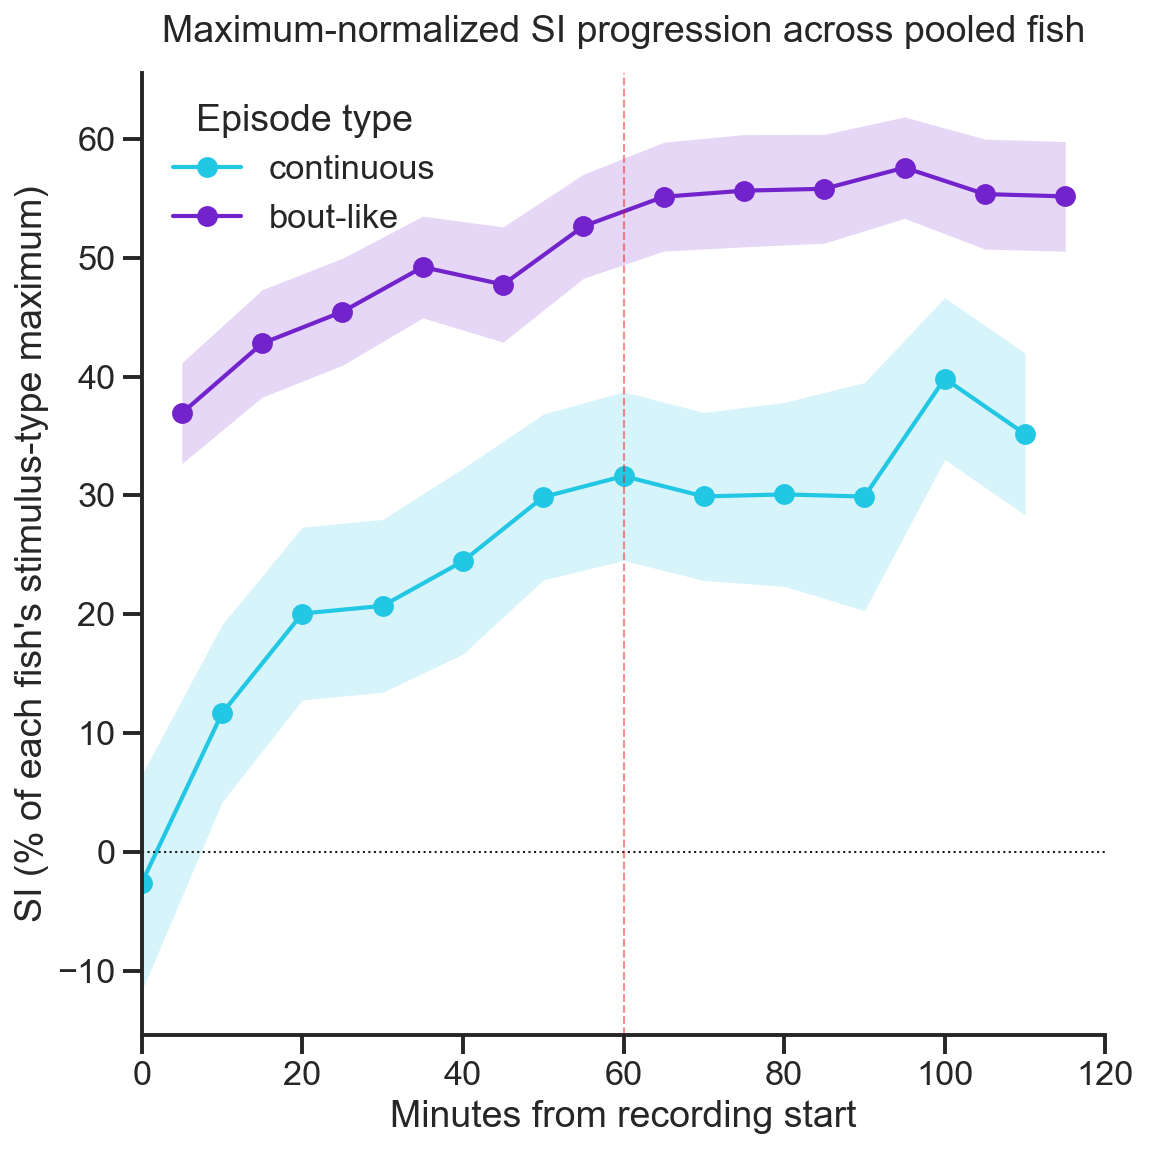

In [15]:
# Plot normalized SI with all valid fish pooled and the selected uncertainty across fish.
fig, ax = plt.subplots(figsize=(8, 8))

for episode_type in SI_NORMALIZED_EPISODE_ORDER:
    dat = si_normalized_all_fish.loc[
        si_normalized_all_fish['episode_type_display'] == episode_type
    ]
    color = SI_NORMALIZED_EPISODE_PALETTE[episode_type]
    ax.plot(
        dat['recording_min'],
        dat['mean_si_pct_fish_max'],
        marker='o',
        linewidth=2,
        label=episode_type,
        color=color,
    )
    ax.fill_between(
        dat['recording_min'],
        dat['mean_si_pct_fish_max'] - dat[selected_uncertainty_column('si_pct_fish_max')],
        dat['mean_si_pct_fish_max'] + dat[selected_uncertainty_column('si_pct_fish_max')],
        alpha=SEM_BAND_ALPHA,
        color=color,
        linewidth=0,
    )

ax.axhline(0, ls=':', color=ZERO_BASELINE_COLOR, linewidth=1)
ax.axvline(REFERENCE_MINUTE, ls='--', color=MIDPOINT_REFERENCE_COLOR, alpha=REFERENCE_LINE_ALPHA, linewidth=1)
ax.set_xlim(0, EPISODES_2H * EPISODE_DURATION_MIN)
ax.set_xlabel('Minutes from recording start')
ax.set_ylabel("SI (% of each fish's stimulus-type maximum)")
ax.set_title('Maximum-normalized SI progression across pooled fish', pad=15)
ax.legend(title='Episode type', frameon=False)
sns.despine()
plt.tight_layout()
fig.savefig(outputDir / 'si_normalized_progression_2026_2h.pdf', bbox_inches='tight')


,animalSet,experiment_label,date_dt,setup,episode_type_display,episode_number,recording_min,mean_si_pct_fish_max,sem_si_pct_fish_max,ci95_si_pct_fish_max,n_fish
0,0,Sel1_10.1_13-02-2026 setup 2,2026-02-13,2,bout-like,2,5.0,30.255962,5.641670,11.478064,34
1,0,Sel1_10.1_13-02-2026 setup 2,2026-02-13,2,bout-like,4,15.0,14.426951,6.079596,12.369032,34
2,0,Sel1_10.1_13-02-2026 setup 2,2026-02-13,2,bout-like,6,25.0,28.115789,6.318006,12.854079,34
3,0,Sel1_10.1_13-02-2026 setup 2,2026-02-13,2,bout-like,8,35.0,30.306820,6.583204,13.393629,34
4,0,Sel1_10.1_13-02-2026 setup 2,2026-02-13,2,bout-like,10,45.0,29.523473,7.435001,15.126623,34


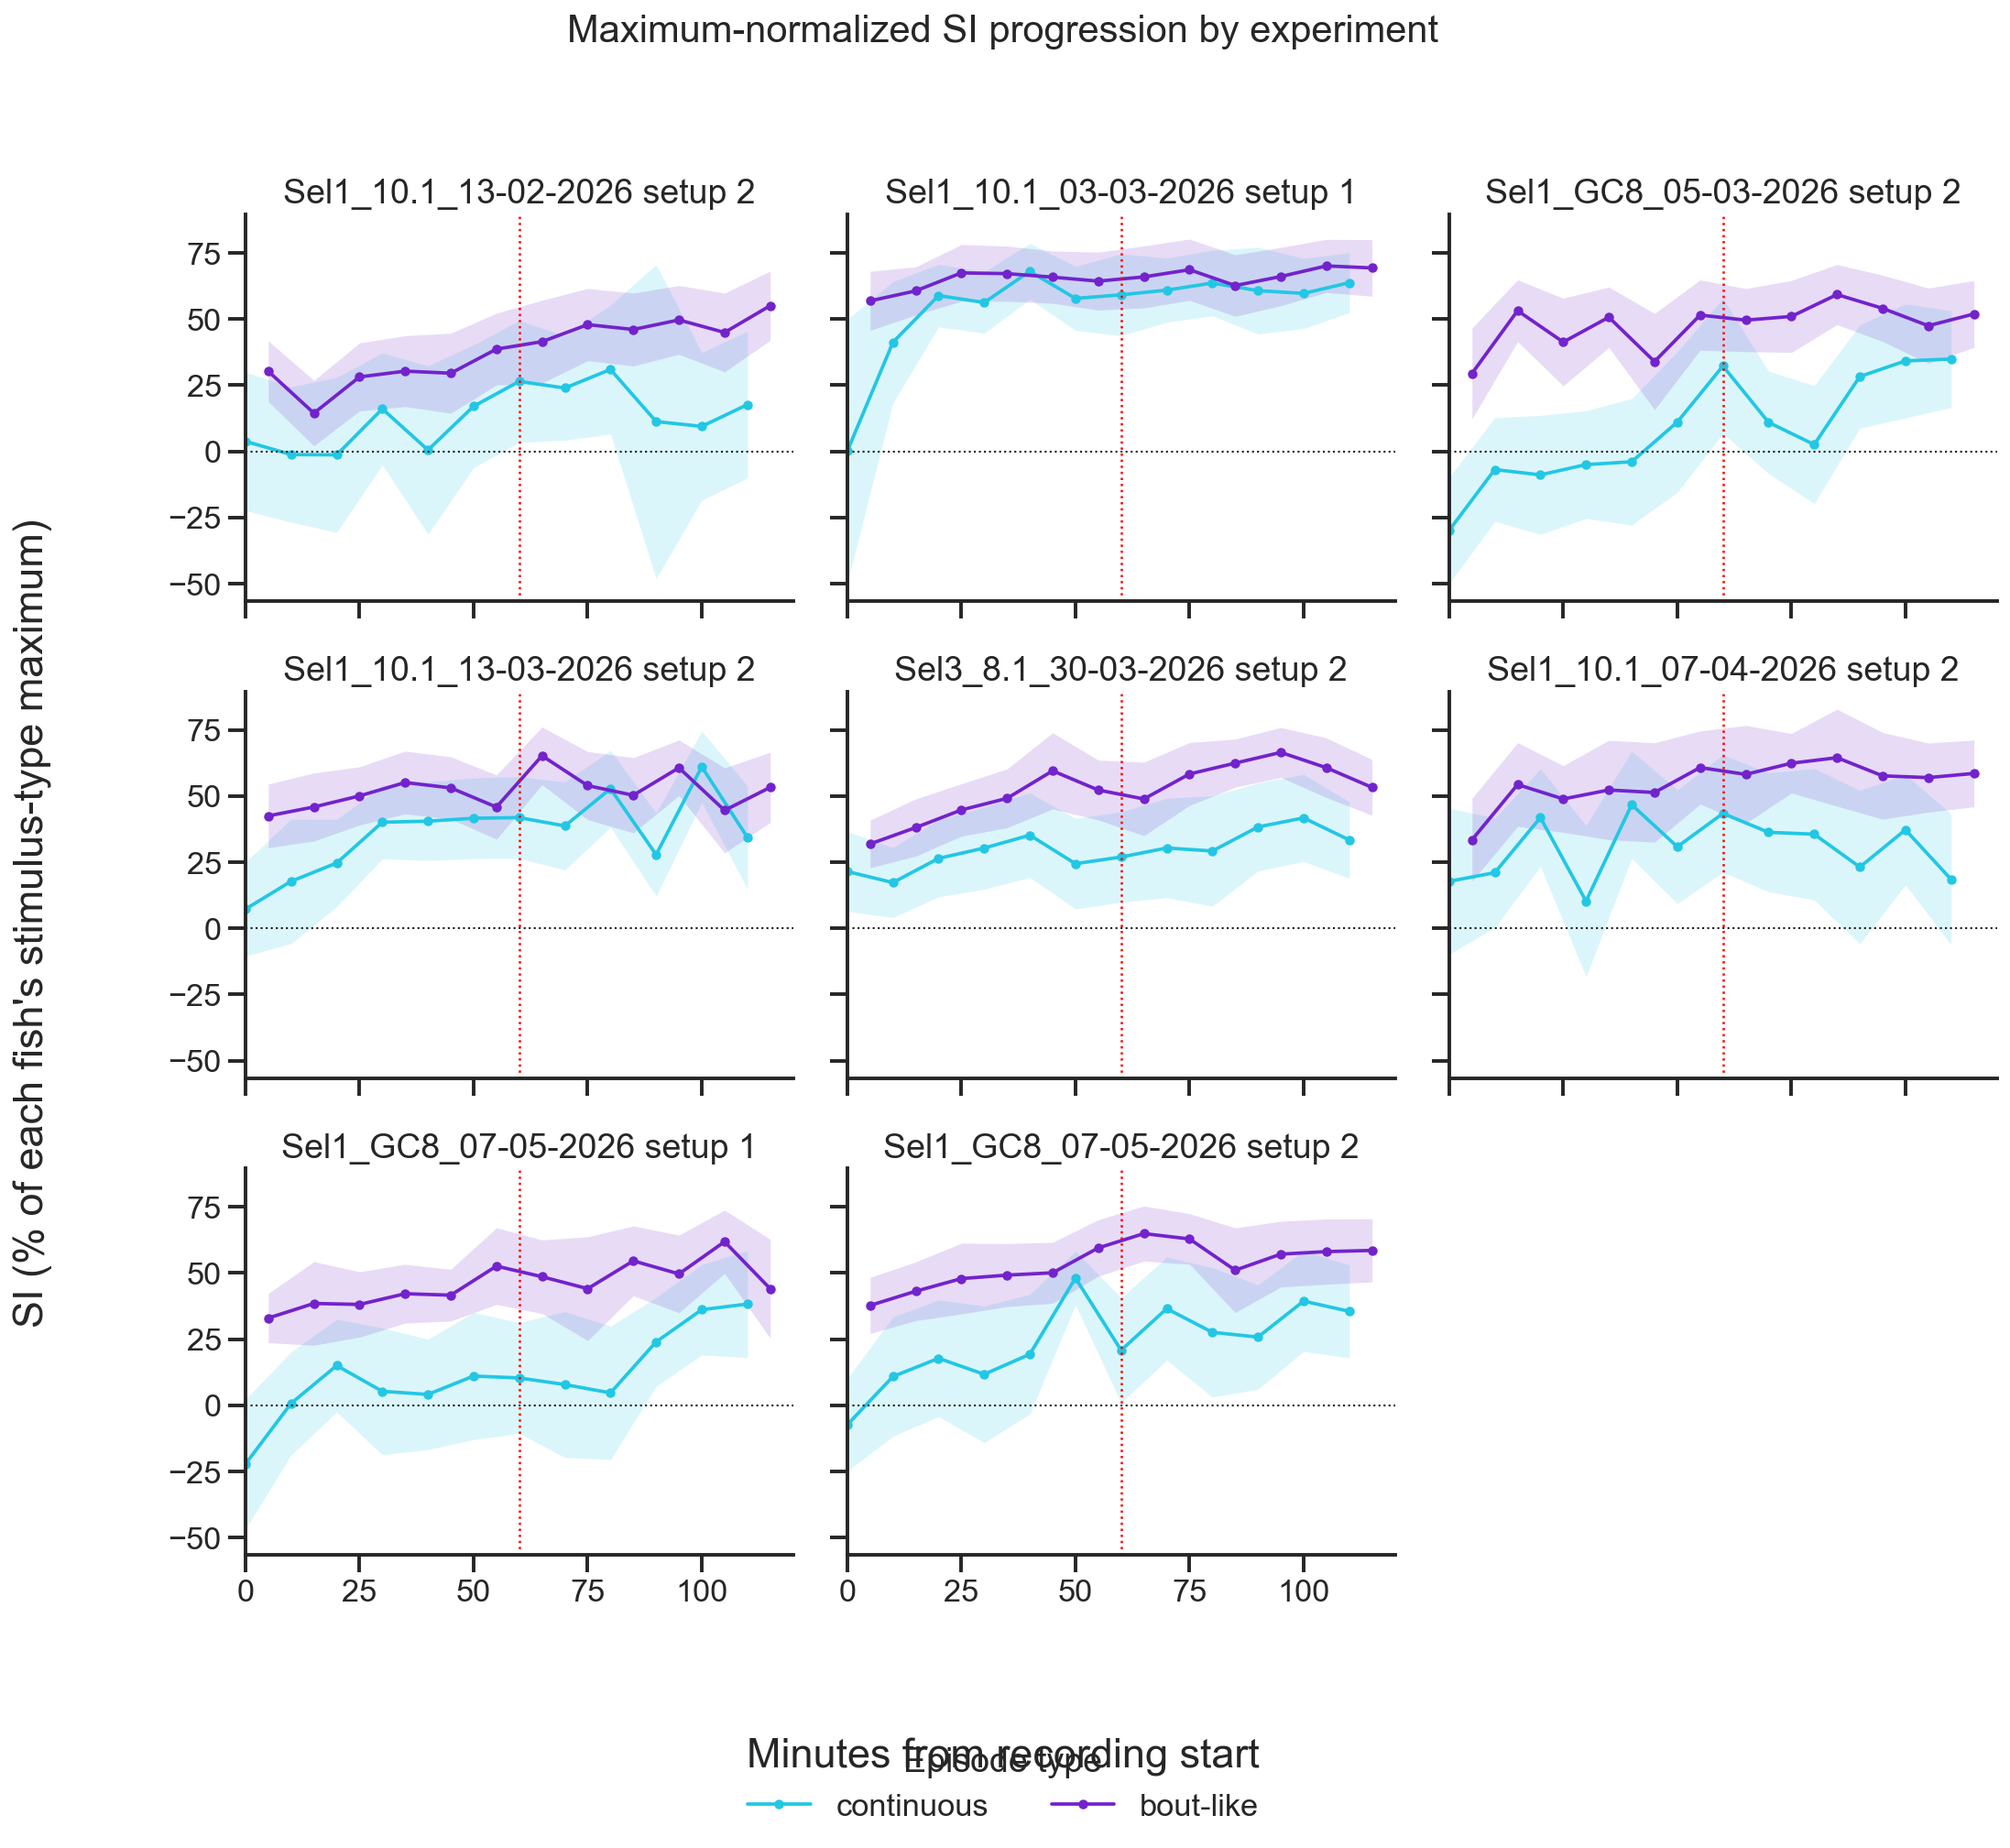

In [16]:
# Order experiment panels chronologically and use a three-column grid for the current nine recordings.
si_normalized_experiment_order = (
    si_normalized_by_experiment[['animalSet', 'experiment_label', 'date_dt', 'setup']]
    .drop_duplicates()
    .sort_values(['date_dt', 'setup', 'animalSet'])
)
n_experiments = len(si_normalized_experiment_order)
ncols = 3
nrows = int(np.ceil(n_experiments / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4.5 * nrows), sharex=True, sharey=True)
axes = np.atleast_1d(axes).ravel()

for ax, (_, experiment) in zip(axes, si_normalized_experiment_order.iterrows()):
    experiment_dat = si_normalized_by_experiment.loc[
        si_normalized_by_experiment['animalSet'] == experiment['animalSet']
    ]
    for episode_type in SI_NORMALIZED_EPISODE_ORDER:
        dat = experiment_dat.loc[
            experiment_dat['episode_type_display'] == episode_type
        ]
        color = SI_NORMALIZED_EPISODE_PALETTE[episode_type]
        ax.plot(
            dat['recording_min'],
            dat['mean_si_pct_fish_max'],
            marker='o',
            linewidth=1.8,
            markersize=4,
            label=episode_type,
            color=color,
        )
        ax.fill_between(
            dat['recording_min'],
            dat['mean_si_pct_fish_max'] - dat[selected_uncertainty_column('si_pct_fish_max')],
            dat['mean_si_pct_fish_max'] + dat[selected_uncertainty_column('si_pct_fish_max')],
            alpha=PER_EXPERIMENT_SEM_BAND_ALPHA,
            color=color,
            linewidth=0,
        )

    ax.axhline(0, ls=':', color=ZERO_BASELINE_COLOR, linewidth=1)
    ax.axvline(REFERENCE_MINUTE, **PER_EXPERIMENT_REFERENCE_LINE_STYLE)
    ax.set_xlim(0, EPISODES_2H * EPISODE_DURATION_MIN)
    ax.set_title(experiment['experiment_label'])

for ax in axes[n_experiments:]:
    ax.set_visible(False)

handles, labels = axes[0].get_legend_handles_labels()
fig.supxlabel('Minutes from recording start', y=0.04)
fig.supylabel("SI (% of each fish's stimulus-type maximum)", x=0.02)
fig.legend(
    handles,
    labels,
    title='Episode type',
    frameon=False,
    loc='lower center',
    bbox_to_anchor=(0.5, 0.0),
    ncol=2,
)
fig.suptitle('Maximum-normalized SI progression by experiment', fontsize=20, y=0.99)
sns.despine(fig=fig)
fig.tight_layout(rect=(0.04, 0.07, 1, 0.96))
fig.savefig(outputDir / 'si_normalized_progression_2026_2h_by_experiment.pdf', bbox_inches='tight')
si_normalized_by_experiment.head()
